# Gene analysis for Fig 1, v2 - cleaned up

## Read in data

In [1]:
# Read in censat regions passing QC
import pandas as pd
import glob
import re

data_dir = '/private/groups/migalab/juklucas/censat_regions/censat_arrays/tables/censat_regions_pass_qc_by_chrom'

dfs = []
for f in glob.glob(f'{data_dir}/censat_regions_pass_qc_chr*.tsv'):
    chrom = re.search(r'chr[\dXYM]+', f).group(0)
    df = pd.read_csv(f, sep='\t')
    df['chrom'] = chrom
    dfs.append(df)

censat_df = pd.concat(dfs, ignore_index=True)
print(censat_df.shape)
censat_df.head()

(4153, 26)


,sample_id,haplotype,assembly_id,sequence_id,region_start,region_end,region_size_bp,feature_count,region_label_bp_json,simplified_label_bp_json,...,contig_size,dist_to_contig_start,dist_to_contig_end,region_not_near_contig_edge,reference_large_array_labels_json,all_large_arrays_represented,sequences_per_assembly_chrom,single_sequence_for_chrom,pass_qc,chrom
0,CHM13,0,chm13v2.0_maskedY_rCRS,CHM13#0#chr18,14298107,21125235,6827128,33,"{""active_hor(S2C18H1L)"": 4967510, ""cenSat(CER)...","{""CER"": 10815, ""HSAT5"": 6819, ""active"": 496751...",...,80542538.0,14298107,59417303.0,True,"[""active""]",True,1.0,True,True,chr18
1,HG00097,1,HG00097_hap1_hprc_r2_v1.0.1,HG00097#1#JBIRDD010000010.1,14135694,19270914,5135220,40,"{""active_hor(S2C18H1L)"": 3113600, ""cenSat(CER)...","{""CER"": 10815, ""HSAT5"": 6832, ""active"": 311360...",...,78710895.0,14135694,59439981.0,True,"[""active""]",True,1.0,True,True,chr18
2,HG00097,2,HG00097_hap2_hprc_r2_v1.0.1,HG00097#2#CM094084.1,14138081,20853464,6715383,33,"{""active_hor(S2C18H1L)"": 4697016, ""cenSat(CER)...","{""CER"": 10815, ""HSAT5"": 6832, ""active"": 469701...",...,80317024.0,14138081,59463560.0,True,"[""active""]",True,1.0,True,True,chr18
3,HG00099,1,HG00099_hap1_hprc_r2_v1.0.1,HG00099#1#CM087325.1,14150536,20957234,6806698,37,"{""active_hor(S2C18H1L)"": 4765242, ""cenSat(CER)...","{""CER"": 10815, ""HSAT5"": 6832, ""active"": 476524...",...,80476601.0,14150536,59519367.0,True,"[""active""]",True,1.0,True,True,chr18
4,HG00099,2,HG00099_hap2_hprc_r2_v1.0.1,HG00099#2#CM087369.1,14095274,20715119,6619845,37,"{""active_hor(S2C18H1L)"": 4536062, ""cenSat(CER)...","{""CER"": 10815, ""HSAT5"": 6832, ""active"": 453606...",...,80141396.0,14095274,59426277.0,True,"[""active""]",True,1.0,True,True,chr18


In [2]:
censat_df[(censat_df["sample_id"] == "HG01071") & (censat_df["haplotype"] == "1")]

,sample_id,haplotype,assembly_id,sequence_id,region_start,region_end,region_size_bp,feature_count,region_label_bp_json,simplified_label_bp_json,...,contig_size,dist_to_contig_start,dist_to_contig_end,region_not_near_contig_edge,reference_large_array_labels_json,all_large_arrays_represented,sequences_per_assembly_chrom,single_sequence_for_chrom,pass_qc,chrom


In [3]:
# Read in gene tables with censat annotation

import pandas as pd
import glob
import re

def parse_attrs(attr_string):
    attrs = {}
    for field in attr_string.split(';'):
        if '=' in field:
            k, v = field.split('=', 1)
            attrs[k.strip()] = v.strip()
    return attrs

records = []
for fpath in glob.glob("/private/groups/patenlab/mira/centrolign/analysis/Fig1_genes/annotate_gff3_with_censat/results/*.genes.censat.tsv"):
    fname = fpath.split("/")[-1]  # e.g. HG03139.1.genes.censat.tsv
    parts = fname.split(".")
    sample_id = parts[0]
    haplotype = int(parts[1])

    with open(fpath) as f:
        for line in f:
            cols = line.strip().split('\t')
            if len(cols) < 9:
                continue

            attrs = parse_attrs(cols[5])

            gene_name = (
                attrs.get('source_gene_common_name') or
                attrs.get('gene_name') or
                attrs.get('Name', '')
            )

            records.append({
                'seqname':          cols[0],
                'start':            int(cols[1]),
                'end':              int(cols[2]),
                'strand':           cols[3],
                'chrom':            cols[4],
                'censat_annot':     cols[6],
                'censat_category':  cols[7],
                'overlap_bp':       int(cols[8]),
                'sample_id':        sample_id,
                'haplotype':        haplotype,
                'gene_name':        gene_name,
                'gene_biotype':     attrs.get('gene_biotype', ''),
                'source_gene':      attrs.get('source_gene', ''),
                'gene_id':          attrs.get('gene_id', ''),
            })

df = pd.DataFrame(records)

# deduplicate: for each gene instance, keep the CenSat annotation with largest overlap
df = (
    df.sort_values('overlap_bp', ascending=False)
    .drop_duplicates(subset=['sample_id', 'haplotype', 'chrom', 'gene_name', 'start', 'end'])
    .reset_index(drop=True)
)

print(df.shape)
print(df.dtypes)
print(df.head())

(170601, 14)
seqname            object
start               int64
end                 int64
strand             object
chrom              object
censat_annot       object
censat_category    object
overlap_bp          int64
sample_id          object
haplotype           int64
gene_name          object
gene_biotype       object
source_gene        object
gene_id            object
dtype: object
      seqname     start       end strand chrom censat_annot censat_category  \
0  CM086448.1  50318045  78300444      .  chr9        HSat3           HSAT3   
1  CM098807.1  46576570  72431025      .  chr9        HSat3           HSAT3   
2  CM089418.1  46764798  72084751      .  chr9        HSat3           HSAT3   
3  CM098780.1  45110754  75844067      .  chr9        HSat3           HSAT3   
4  CM086514.1  49994128  74746601      .  chr9        HSat3           HSAT3   

   overlap_bp sample_id  haplotype gene_name            gene_biotype  \
0    22897328   HG02300          2   DUX4L50  unprocessed_pseu

In [4]:
def classify_biotype_5(b):
    if b == "protein_coding" or b in IG_TR: return "protein-coding"
    elif b == "lncRNA":                      return "lncRNA"
    elif "pseudogene" in b:                  return "pseudogene"
    elif b in ("snRNA", "snoRNA", "miRNA", "rRNA", "misc_RNA"):
                                             return "other ncRNA"
    else:                                    return "other"


# ── classify biotypes ─────────────────────────────────────────────────────────
IG_TR = {"IG_V_gene", "IG_D_gene", "IG_J_gene", "IG_C_gene",
         "TR_V_gene", "TR_D_gene", "TR_J_gene", "TR_C_gene"}


df["biotype_class"] = df["gene_biotype"].apply(classify_biotype_5)

In [5]:
print(df["gene_biotype"].value_counts().to_string())


gene_biotype
processed_pseudogene                  39175
unprocessed_pseudogene                35348
protein_coding                        23347
lncRNA                                17456
transcribed_unprocessed_pseudogene    17179
rRNA_pseudogene                        6776
transcribed_processed_pseudogene       6539
IG_V_pseudogene                        5850
IG_V_gene                              5187
miRNA                                  4844
snRNA                                  3868
misc_RNA                               1907
rRNA                                   1736
snoRNA                                  696
unitary_pseudogene                      296
unknown_likely_coding                   245
Mt_rRNA                                  54
Mt_tRNA                                  48
IG_D_gene                                25
transcribed_unitary_pseudogene           11
IG_C_gene                                10
IG_J_gene                                 4


In [6]:
### Create bed files of censat regions for all samples 

import sys
from pathlib import Path
import pandas as pd
import glob

CENSAT_DIR   = '/private/groups/migalab/juklucas/censat_regions/censat_arrays/tables/censat_regions_pass_qc_by_chrom'
CAT_GENE_IDX = '/private/home/juklucas/github/censat_paper/data_tables/annotation/genes/cat_genes_hprc_r2_v1.3.index.csv'

outdir = Path(f'/private/groups/patenlab/mira/centrolign/analysis/Fig1_genes/extract_censat_from_gff3/all_chroms_out')
bed_dir = outdir / 'beds'
bed_dir.mkdir(parents=True, exist_ok=True)
# Load all chromosomes at once
all_tsvs = glob.glob(f'{CENSAT_DIR}/censat_regions_pass_qc_chr*.tsv')
censat_df = pd.concat(
    [pd.read_csv(f, sep='\t') for f in all_tsvs],
    ignore_index=True
)
censat_df['haplotype'] = censat_df['haplotype'].astype(str)
print(f'Loaded {len(censat_df)} censat regions across all chromosomes')

cat_idx = pd.read_csv(CAT_GENE_IDX)
cat_idx['haplotype'] = cat_idx['haplotype'].astype(str)

job_rows = []
for (sample_id, haplotype), regions in censat_df.groupby(['sample_id', 'haplotype']):
    sample_id = str(sample_id)
    haplotype = str(haplotype)

    match = cat_idx[
        (cat_idx['sample_id'] == sample_id) &
        (cat_idx['haplotype'] == haplotype)
    ]
    if match.empty:
        continue
    gff3_path = Path(match.iloc[0]['location'])
    if not gff3_path.exists():
        print(f'WARN: missing GFF3 for {sample_id} hap{haplotype}')
        continue

    # One BED per sample with all chromosomes' regions
    bed_path = bed_dir / f'{sample_id}.{haplotype}.bed'
    regions[['sequence_id', 'region_start', 'region_end', 'chrom_assignment']].to_csv(
        bed_path, sep='\t', header=False, index=False
    )


    job_rows.append({
        'sample_id': sample_id,
        'haplotype': haplotype,
        'gff3_path': str(gff3_path),
        'bed_path':  str(bed_path),
    })

jobs_path = outdir / 'jobs.tsv'
pd.DataFrame(job_rows).to_csv(jobs_path, sep='\t', index=False)
print(f'Wrote {len(job_rows)} jobs to {jobs_path}')
print(f'SLURM array range: 0-{len(job_rows) - 1}')

Loaded 4153 censat regions across all chromosomes
Wrote 462 jobs to /private/groups/patenlab/mira/centrolign/analysis/Fig1_genes/extract_censat_from_gff3/all_chroms_out/jobs.tsv
SLURM array range: 0-461


In [7]:
# read in array ranges 
import pandas as pd
import glob
import os

ARRAY_RANGE_DIR = '/private/groups/patenlab/mira/centrolign/analysis/Fig1_genes/extract_censat_from_gff3/all_chroms_out/beds'

# ── load array ranges ─────────────────────────────────────────────────────────
range_records = []
for bed_path in glob.glob(f'{ARRAY_RANGE_DIR}/*.bed'):
    fname     = os.path.basename(bed_path)      # e.g. HG00097.1.bed
    parts     = fname.replace('.bed','').split('.')
    sample_id = parts[0]
    haplotype = parts[1]

    with open(bed_path) as f:
        for line in f:
            cols = line.strip().split('\t')
            if len(cols) < 4:
                continue
            seq          = cols[0]              # e.g. HG00097#1#CM094060.1
            array_start  = int(cols[1])
            array_end    = int(cols[2])
            chrom        = cols[3]              # e.g. chr1
            range_records.append({
                'sample_id':   sample_id,
                'haplotype':   haplotype,
                'seq':         seq,
                'chrom':       chrom,
                'array_start': array_start,
                'array_end':   array_end,
            })

ranges_df = pd.DataFrame(range_records)
print(f"Loaded {len(ranges_df)} array ranges across {ranges_df['sample_id'].nunique()} samples")
print(ranges_df.head())

Loaded 4090 array ranges across 231 samples
  sample_id haplotype                          seq  chrom  array_start  \
0   NA18970         1  NA18970#1#JBKABU010000018.1  chr18     14129080   
1   NA18970         1         NA18970#1#CM101477.1  chr20     25899967   
2   NA18970         1         NA18970#1#CM101467.1   chr3     90325526   
3   NA18970         1         NA18970#1#CM101473.1  chr12     34178601   
4   NA18970         1  NA18970#1#JBKABU010000019.1  chr19     21001722   

   array_end  
0   20015963  
1   34002937  
2   95683668  
3   38161038  
4   31076511  


In [8]:
ranges_df[(ranges_df["sample_id"] == "HG01071") & (ranges_df["haplotype"] == "1")]


,sample_id,haplotype,seq,chrom,array_start,array_end
3836,HG01071,1,HG01071#1#CM089125.1,chr20,25844014,32903482
3837,HG01071,1,HG01071#1#CM089121.1,chr12,34080546,37991141
3838,HG01071,1,HG01071#1#CM089124.1,chr19,21263059,30316076
3839,HG01071,1,HG01071#1#CM089120.1,chr11,48753068,57550340
3840,HG01071,1,HG01071#1#CM089119.1,chr10,38518535,43239465
3841,HG01071,1,HG01071#1#CM089115.1,chr5,46242319,51749323
3842,HG01071,1,HG01071#1#CM089117.1,chr8,42894030,47453043
3843,HG01071,1,HG01071#1#CM089126.1,chrX,57589258,62564712
3844,HG01071,1,HG01071#1#CM089122.1,chr16,35941720,53778495
3845,HG01071,1,HG01071#1#CM089118.1,chr9,44530066,65518239


In [9]:
import os
# ── load censat BEDs and classify CT intervals ────────────────────────────────
embedded_ct_records = []

CENSAT_BED_DIR  = '/private/groups/migalab/juklucas/censat_regions/censat_beds'

for bed_path in glob.glob(f'{CENSAT_BED_DIR}/*.cenSat.bed'):
    fname     = os.path.basename(bed_path)
    parts     = fname.split('_')
    sample_id = parts[0]
    haplotype = parts[1].replace('hap', '')

    # get array ranges for this sample/haplotype
    sample_ranges = ranges_df[
        (ranges_df['sample_id'] == sample_id) &
        (ranges_df['haplotype'] == haplotype)
    ].set_index('seq')

    if sample_ranges.empty:
        continue

    rows = []
    with open(bed_path) as f:
        for line in f:
            if line.startswith('track'):
                continue
            cols = line.strip().split('\t')
            if len(cols) < 4:
                continue
            seq   = cols[0]
            start = int(cols[1])
            end   = int(cols[2])
            annot = cols[3]
            rows.append({'seq': seq, 'start': start, 'end': end, 'annot': annot})

    if not rows:
        continue

    bed_df = pd.DataFrame(rows)

    # only process CT intervals on contigs we have array ranges for
    ct_df = bed_df[bed_df['annot'].str.match(r'^[Cc][Tt]', na=False)].copy()
    ct_df = ct_df[ct_df['seq'].isin(sample_ranges.index)]

    for _, row in ct_df.iterrows():
        arr        = sample_ranges.loc[row['seq']]
        array_start = arr['array_start']
        array_end   = arr['array_end']
        chrom       = arr['chrom']

        # peripheral if CT interval touches either boundary of the array range
        peripheral = (row['start'] <= array_start) | (row['end'] >= array_end)
        embedded   = not peripheral

        embedded_ct_records.append({
            'sample_id':   sample_id,
            'haplotype':   haplotype,
            'seq':         row['seq'],
            'chrom':       chrom,
            'ct_start':    row['start'],
            'ct_end':      row['end'],
            'annot':       row['annot'],
            'array_start': array_start,
            'array_end':   array_end,
            'embedded':    embedded,
            'peripheral':  peripheral,
        })

embedded_ct_df = pd.DataFrame(embedded_ct_records)

print(f"Total CT intervals:  {len(embedded_ct_df)}")
print(f"Embedded:            {embedded_ct_df['embedded'].sum()}")
print(f"Peripheral:          {embedded_ct_df['peripheral'].sum()}")

Total CT intervals:  34032
Embedded:            29454
Peripheral:          4578


In [10]:
CHROM_ORDER = [f"chr{i}" for i in list(range(1, 23)) + ["X", "Y"]]

# ── filter gene df to embedded CT genes only ──────────────────────────────────
ct_genes = df[df['censat_category'] == 'CT'].copy()
print(f"Total CT genes before filtering: {len(ct_genes)}")

embedded_ct = embedded_ct_df[embedded_ct_df['embedded']].copy()

# merge on sample/haplotype/chrom then filter by coordinate overlap

ct_genes['haplotype']       = ct_genes['haplotype'].astype(str)
embedded_ct['haplotype']    = embedded_ct['haplotype'].astype(str)

ct_genes_embedded = ct_genes.merge(
    embedded_ct[['sample_id', 'haplotype', 'chrom', 'ct_start', 'ct_end']],
    on=['sample_id', 'haplotype', 'chrom'],
    how='inner'
)

# require gene overlaps the CT interval
ct_genes_embedded = ct_genes_embedded[
    (ct_genes_embedded['start'] < ct_genes_embedded['ct_end']) &
    (ct_genes_embedded['end']   > ct_genes_embedded['ct_start'])
].drop(columns=['ct_start', 'ct_end']).drop_duplicates(
    subset=['sample_id', 'haplotype', 'chrom', 'gene_name', 'start', 'end']
).reset_index(drop=True)

print(f"Genes in embedded CT regions:    {len(ct_genes_embedded)}")
print()
print("Biotype breakdown:")
print(ct_genes_embedded['biotype_class'].value_counts())
print()
print("Chromosome breakdown:")
print(ct_genes_embedded['chrom'].value_counts().reindex(CHROM_ORDER).dropna())

Total CT genes before filtering: 154669
Genes in embedded CT regions:    66603

Biotype breakdown:
biotype_class
pseudogene        43737
protein-coding    12572
lncRNA             5646
other ncRNA        4551
other                97
Name: count, dtype: int64

Chromosome breakdown:
chrom
chr1      2289.0
chr2      7316.0
chr3       195.0
chr4       510.0
chr6       675.0
chr7      5459.0
chr8      2339.0
chr9      3798.0
chr10     2352.0
chr11    16497.0
chr12      853.0
chr13      162.0
chr14      762.0
chr15      114.0
chr16     4847.0
chr17     2114.0
chr18     1827.0
chr19    10429.0
chr20     3463.0
chr22      219.0
chrY       383.0
Name: count, dtype: float64


In [11]:
## Combine the "embedded" CT genes with the rest of the satellite classes
# non-CT genes from original df
non_ct_genes = df[df['censat_category'] != 'CT'].copy()

# combine with embedded CT genes
df_filtered = pd.concat([non_ct_genes, ct_genes_embedded], ignore_index=True)

print(f"Non-CT genes:          {len(non_ct_genes)}")
print(f"Embedded CT genes:     {len(ct_genes_embedded)}")
print(f"Total after filtering: {len(df_filtered)}")
print(df_filtered['censat_category'].value_counts())

Non-CT genes:          15932
Embedded CT genes:     66603
Total after filtering: 82535
censat_category
CT             66603
bSat            5358
rDNA            4996
SST1            2068
HSAT5           1468
HSAT4            634
mon              528
CER              255
hor              213
SATR             138
active_hor        96
HSAT3             88
HSAT1             68
HSAT2             11
acrocentric        8
GAP                2
mixedAlpha         1
Name: count, dtype: int64


In [12]:
# ── enforce consistent haplotype type ─────────────────────────────────────────
df_filtered["haplotype"] = df_filtered["haplotype"].astype(str)
censat_df["haplotype"]   = censat_df["haplotype"].astype(str)

# ── filter to haplotype×chrom combinations that pass QC ──────────────────────
qc_pass = (
    censat_df[censat_df["pass_qc"] == True][["sample_id", "haplotype", "chrom_assignment"]]
    .drop_duplicates()
    .rename(columns={"chrom_assignment": "chrom"})
)

df_filtered = df_filtered.merge(
    qc_pass, on=["sample_id", "haplotype", "chrom"], how="inner"
).reset_index(drop=True)

# ── summary ───────────────────────────────────────────────────────────────────
n_genes = len(df_filtered)
n_haps  = df_filtered[["sample_id", "haplotype"]].drop_duplicates().shape[0]
print(f"Genes:              {n_genes}")
print(f"Unique haplotypes:  {n_haps}")
print()
print("Haplotypes per chrom:")
haps_per_chrom = (
    df_filtered
    .groupby("chrom")[["sample_id", "haplotype"]]
    .apply(lambda x: x.drop_duplicates().shape[0])
    .rename("n_haplotypes")
    .reindex(CHROM_ORDER)
    .dropna()
    .astype(int)
)
print(haps_per_chrom.to_string())


Genes:              82535
Unique haplotypes:  461

Haplotypes per chrom:
chrom
chr1      95
chr2     144
chr3      53
chr4      87
chr5      11
chr6      89
chr7     231
chr8     320
chr9     258
chr10    131
chr11    193
chr12    367
chr13      6
chr14     16
chr15     10
chr16    212
chr17    124
chr18    119
chr19    249
chr20    216
chr21      2
chr22      3
chrX     228
chrY       9


### Sanity check: Make sure periphery is still censat 

In [13]:
import os
import glob
import pandas as pd
import numpy as np

CENSAT_BED_DIR  = '/private/groups/migalab/juklucas/censat_regions/censat_beds'
CENSAT_TSV_DIR  = '/private/groups/migalab/juklucas/censat_regions/censat_arrays/tables/censat_regions_pass_qc_by_chrom'
FLANK_BP        = 100_000  # look this many bp into the edge of each region

# load all array regions
all_tsvs = glob.glob(f'{CENSAT_TSV_DIR}/censat_regions_pass_qc_chr*.tsv')
regions_df = pd.concat([pd.read_csv(f, sep='\t') for f in all_tsvs], ignore_index=True)
regions_df['haplotype'] = regions_df['haplotype'].astype(str)
regions_df = regions_df[regions_df['pass_qc'] == True]

# build sample → BED path mapping
bed_map = {}
for bed_path in glob.glob(f'{CENSAT_BED_DIR}/*.cenSat.bed'):
    fname = os.path.basename(bed_path)
    # parse sample_id and haplotype from filename
    parts = fname.replace('.cenSat.bed', '').split('_')
    sample_id = parts[0]
    hap_raw   = parts[1]  # hap1 / hap2 / mat / pat
    haplotype = hap_raw.replace('hap', '').replace('mat', '1').replace('pat', '2')
    bed_map[(sample_id, haplotype)] = bed_path

records = []
processed = 0

for (sample_id, haplotype), grp in regions_df.groupby(['sample_id', 'haplotype']):
    bed_path = bed_map.get((str(sample_id), str(haplotype)))
    if bed_path is None:
        continue

    # load censat BED for this sample
    rows = []
    with open(bed_path) as f:
        for line in f:
            if line.startswith('track'):
                continue
            cols = line.strip().split('\t')
            if len(cols) < 4:
                continue
            # strip SAMPLE#HAP# prefix from sequence id
            seq_parts = cols[0].split('#')
            seq = seq_parts[2] if len(seq_parts) == 3 else cols[0]
            rows.append({'seq': seq, 'start': int(cols[1]),
                         'end': int(cols[2]), 'annot': cols[3]})
    if not rows:
        continue
    bed_df = pd.DataFrame(rows)

    for _, region in grp.iterrows():
        seq         = region['sequence_id'].split('#')[-1]  # strip prefix
        reg_start   = region['region_start']
        reg_end     = region['region_end']
        chrom       = region['chrom_assignment']
        seq_bed     = bed_df[bed_df['seq'] == seq]

        for side, window_start, window_end in [
            ('left',  reg_start,            reg_start + FLANK_BP),
            ('right', reg_end   - FLANK_BP, reg_end),
        ]:
            hits = seq_bed[
                (seq_bed['start'] < window_end) &
                (seq_bed['end']   > window_start)
            ]
            for _, hit in hits.iterrows():
                records.append({
                    'sample_id': sample_id,
                    'haplotype': haplotype,
                    'chrom':     chrom,
                    'side':      side,
                    'annot':     hit['annot'],
                })
    processed += 1

print(f"Processed {processed} sample×haplotype pairs")
periph_df = pd.DataFrame(records)

# simplify annotations using same categories
def simplify(a):
    if   re.match(r'^active_hor', a): return 'active_hor'
    elif re.match(r'^dhor',       a): return 'dhor'
    elif re.match(r'^hor',        a): return 'hor'
    elif re.match(r'^mixedAlpha', a): return 'mixedAlpha'
    elif re.match(r'^mon',        a): return 'mon'
    elif re.search(r'HSat1|HSAT1', a): return 'HSAT1'
    elif re.search(r'HSat2|HSAT2', a): return 'HSAT2'
    elif re.search(r'HSat3|HSAT3', a): return 'HSAT3'
    elif re.search(r'[Cc][Tt]',   a): return 'CT'
    elif re.search(r'bSat',       a): return 'bSat'
    elif re.search(r'gSat',       a): return 'gSat'
    else: return 'other'

periph_df['category'] = periph_df['annot'].apply(simplify)

print(f"\nLeft edge annotation counts (top 20):")
print(periph_df[periph_df['side']=='left']['category'].value_counts().head(20))
print(f"\nRight edge annotation counts (top 20):")
print(periph_df[periph_df['side']=='right']['category'].value_counts().head(20))

print(f"\nBy chrom and side:")
print(
    periph_df.groupby(['chrom', 'side', 'category'])
    .size()
    .reset_index(name='count')
    .sort_values(['chrom', 'side', 'count'], ascending=[True, True, False])
    .groupby(['chrom', 'side'])
    .head(3)
    .to_string()
)
print("\nRaw 'other' annotations (value counts):")
print(periph_df[periph_df['category'] == 'other']['annot'].value_counts().to_string())



Processed 462 sample×haplotype pairs

Left edge annotation counts (top 20):
category
CT            1934
other         1482
mon           1117
HSAT3          355
bSat           320
hor            303
gSat           174
HSAT2          145
HSAT1          143
mixedAlpha     137
Name: count, dtype: int64

Right edge annotation counts (top 20):
category
CT            1436
other          974
mon            803
hor            407
gSat           280
bSat           271
mixedAlpha     266
dhor           254
HSAT2          166
active_hor     105
HSAT3           94
Name: count, dtype: int64

By chrom and side:
     chrom   side    category  count
0     chr1   left         hor    303
1     chr1   left  mixedAlpha    137
2     chr1  right          CT     44
4     chr1  right        gSat     42
3     chr1  right       HSAT2      2
7    chr10   left       HSAT3    131
6    chr10   left       HSAT2     13
5    chr10   left          CT      6
8    chr10  right          CT    130
11   chr10  right        

In [14]:
### Filter periphery for rDNA, acro, annot categories 

mask = (
    (df_filtered["censat_category"] == "rDNA") |
    (df_filtered["censat_annot"].str.contains("ACRO", case=False, na=False)) |
    (df_filtered["censat_annot"].str.contains("annot", case=False, na=False))
)

print(f"Removing {mask.sum()} rows ({df_filtered[mask]['censat_category'].value_counts().to_dict()})")
df_filtered = df_filtered[~mask].reset_index(drop=True)
print(f"Remaining rows: {len(df_filtered)}")


Removing 5005 rows ({'rDNA': 4996, 'acrocentric': 8, 'SATR': 1})
Remaining rows: 77530


## Gene summary plots 

In [15]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

In [16]:
# --- group definitions ---
BIOTYPE_MAP = {
    "protein-coding": ["protein-coding"],
    "pseudogene":     ["pseudogene"],
    "noncoding":      ["lncRNA", "other ncRNA", "other"],
}
SAT_GROUPS = {
    "alpha": ["active_hor", "hor", "mixedAlpha", "mon"],
    "HSAT":  ["HSAT1", "HSAT2", "HSAT3", "HSAT4", "HSAT5"],
    "bSat":  ["bSat"],
    "SATR":  ["SATR"],
    "SST1":  ["SST1"],
    "CT":    ["CT"],
}
SAT_ORDER_NEW    = ["alpha", "HSAT", "bSat", "SATR", "SST1", "CT"]
BIOTYPE_ORDER_3  = ["protein-coding", "pseudogene", "noncoding"]
BIOTYPE_COLORS_3 = {"protein-coding": "#2166ac", "pseudogene": "#f46d43", "noncoding": "#74add1"}

Total haplotypes: 461


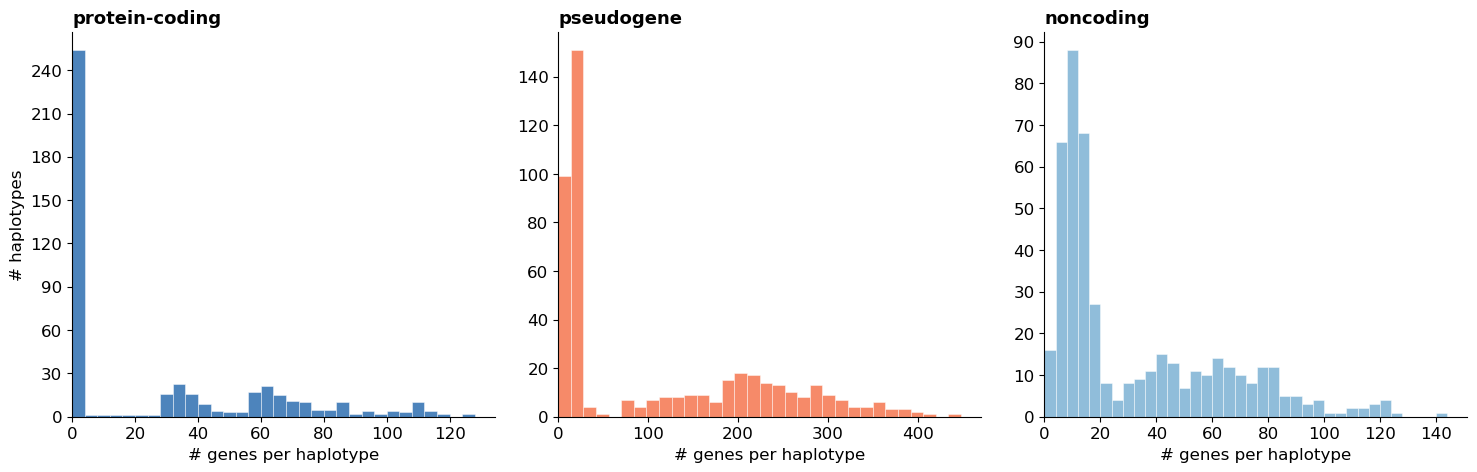

55.3% of haplotypes have <10 protein-coding:   (n=461)
11.3% of haplotypes have <10 pseudogene:   (n=461)
27.1% of haplotypes have <10 noncoding:   (n=461)


In [17]:
import numpy as np

df_filtered["haplotype"] = df_filtered["haplotype"].astype(str)

# rebuild biotype grouping
bio_to_biogrp = {b: g for g, bs in BIOTYPE_MAP.items() for b in bs}
df_filtered["biotype_group"] = df_filtered["biotype_class"].map(bio_to_biogrp)
df_plot = df_filtered.dropna(subset=["biotype_group"])

per_hap_bio = (
    df_plot
    .groupby(["sample_id", "haplotype", "biotype_group"])
    .size()
    .reset_index(name="count")
)

all_haps = df_filtered[["sample_id", "haplotype"]].drop_duplicates().reset_index(drop=True)
print(f"Total haplotypes: {len(all_haps)}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5), gridspec_kw={"wspace": 0.15})

for ax, bio in zip(axes, BIOTYPE_ORDER_3):
    sub    = per_hap_bio[per_hap_bio["biotype_group"] == bio][["sample_id", "haplotype", "count"]]
    merged = all_haps.merge(sub, on=["sample_id", "haplotype"], how="left").fillna(0)
    vals   = merged["count"].values
    color  = BIOTYPE_COLORS_3[bio]

    step = max(1, int(vals.max()) // 30)
    bins = range(0, int(vals.max()) + step + 1, step)
    ax.hist(vals, bins=bins, color=color, alpha=0.8, edgecolor="white", linewidth=0.4)

    ax.set_title(bio, fontsize=13, fontweight="bold", loc="left")
    ax.set_xlabel("# genes per haplotype", fontsize=12)
    ax.set_ylabel("# haplotypes" if bio == BIOTYPE_ORDER_3[0] else "", fontsize=12)
    ax.set_xlim(left=0)
    ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(labelsize=12)

plt.show()

for bio in BIOTYPE_ORDER_3:
    sub    = per_hap_bio[per_hap_bio["biotype_group"] == bio][["sample_id", "haplotype", "count"]]
    merged = all_haps.merge(sub, on=["sample_id", "haplotype"], how="left").fillna(0)
    vals   = merged["count"].values
    pct    = 100 * (vals < 10).sum() / len(vals)
    print(f"{pct:.1f}% of haplotypes have <10 {bio}:   (n={len(vals)})")

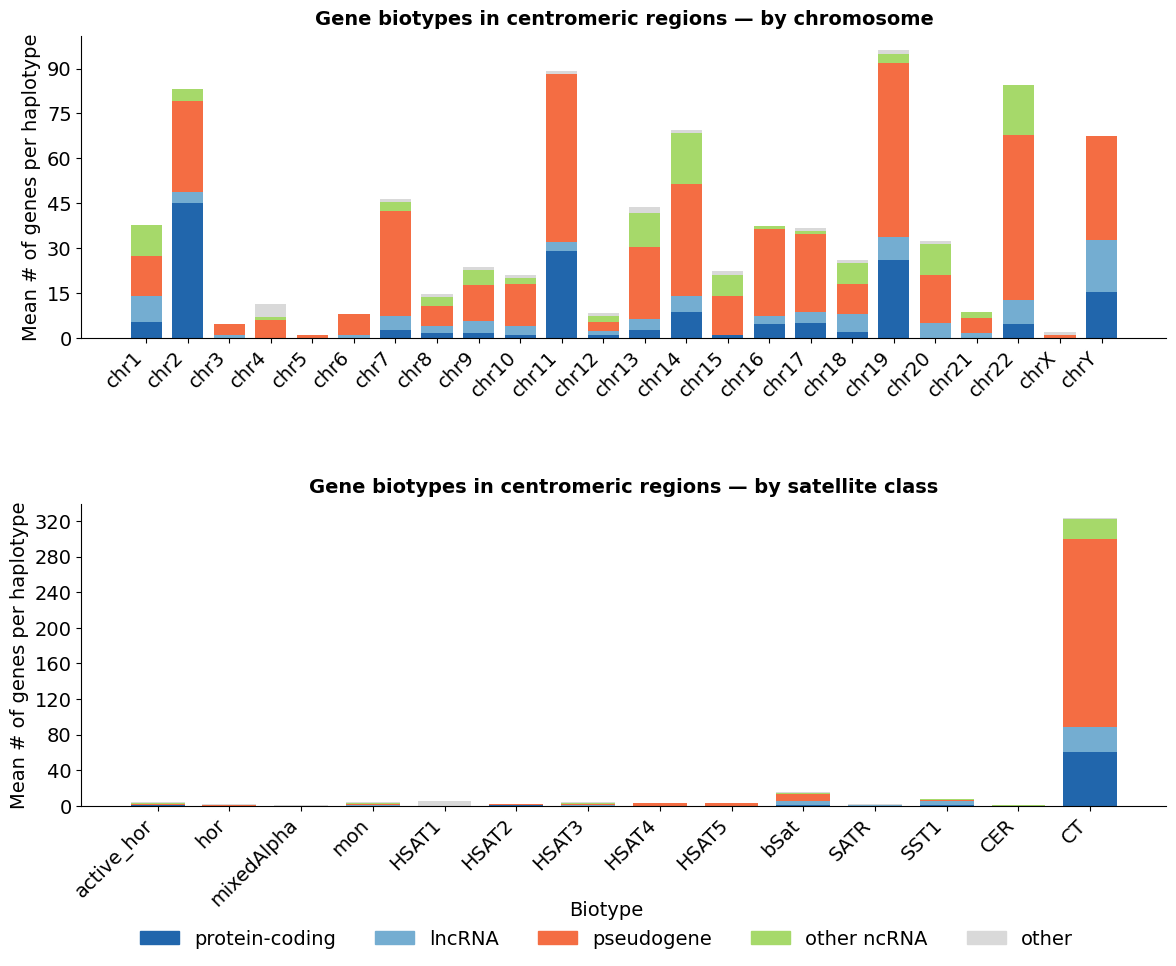

In [18]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

# count per haplotype first, then average across haplotypes
per_hap = (
    df_filtered.groupby(["sample_id", "haplotype", "chrom", "biotype_class"])
    .size()
    .reset_index(name="count")
)

chrom_counts = (
    per_hap.groupby(["chrom", "biotype_class"])["count"]
    .mean()
    .unstack(fill_value=0)
)

sat_counts = (
    df_filtered.groupby(["sample_id", "haplotype", "censat_category", "biotype_class"])
    .size()
    .reset_index(name="count")
    .groupby(["censat_category", "biotype_class"])["count"]
    .mean()
    .unstack(fill_value=0)
)


# ── config ────────────────────────────────────────────────────────────────────
BIOTYPE_ORDER = ["protein-coding", "lncRNA", "pseudogene", "other ncRNA", "other"]

BIOTYPE_COLORS = {
    "protein-coding": "#2166ac",
    "lncRNA":         "#74add1",
    "pseudogene":     "#f46d43",
    "other ncRNA":    "#a6d96a",
    "other":   "#d9d9d9",
}

CHROM_ORDER = [f"chr{i}" for i in list(range(1, 23)) + ["X", "Y"]]

SAT_ORDER = [
    "active_hor", "hor", "dhor", "mixedAlpha", "mon",
    "HSAT1", "HSAT2", "HSAT3", "HSAT4", "HSAT5",
    "bSat", "gSat", "SATR", "SST1", "CER",
    "rDNA", "acrocentric", "CT", "other",
]

# ── plot ──────────────────────────────────────────────────────────────────────
def make_stacked_bar(ax, pivot, title, xlabel, category_order, color_map, biotype_order):
    cols  = [b for b in biotype_order if b in pivot.columns]
    pivot = pivot[cols]
    valid = [c for c in category_order if c in pivot.index]
    pivot = pivot.reindex(valid).fillna(0)

    bottom = np.zeros(len(pivot))
    x      = np.arange(len(pivot))

    for biotype in cols:
        vals = pivot[biotype].values
        ax.bar(x, vals, bottom=bottom,
               color=color_map[biotype], label=biotype,
               width=0.75, linewidth=0)
        bottom += vals

    ax.set_xticks(x)
    ax.set_xticklabels(pivot.index, rotation=45, ha="right", fontsize=14)
    ax.set_title(title, fontsize=14, fontweight="bold", pad=8)
    ax.set_xlabel(xlabel, fontsize=14)
    ax.set_ylabel("Mean # of genes per haplotype", fontsize=14)
    ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(axis="y", labelsize=14)


fig, axes = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={"hspace": 0.55})

make_stacked_bar(axes[0], chrom_counts,
    title="Gene biotypes in centromeric regions — by chromosome",
    xlabel="", category_order=CHROM_ORDER,
    color_map=BIOTYPE_COLORS, biotype_order=BIOTYPE_ORDER)

make_stacked_bar(axes[1], sat_counts,
    title="Gene biotypes in centromeric regions — by satellite class",
    xlabel="", category_order=SAT_ORDER,
    color_map=BIOTYPE_COLORS, biotype_order=BIOTYPE_ORDER)

handles = [plt.Rectangle((0,0),1,1, color=BIOTYPE_COLORS[b], label=b) for b in BIOTYPE_ORDER]
fig.legend(handles=handles, title="Biotype", loc="lower center",
           ncol=5, fontsize=14, title_fontsize=14, frameon=False, bbox_to_anchor=(0.5, -0.05))
#plt.savefig("biotype_summary.pdf", bbox_inches="tight", dpi=200)
plt.show()

In [19]:
###  of Genes per haplotypes for protein coding and noncoding genes

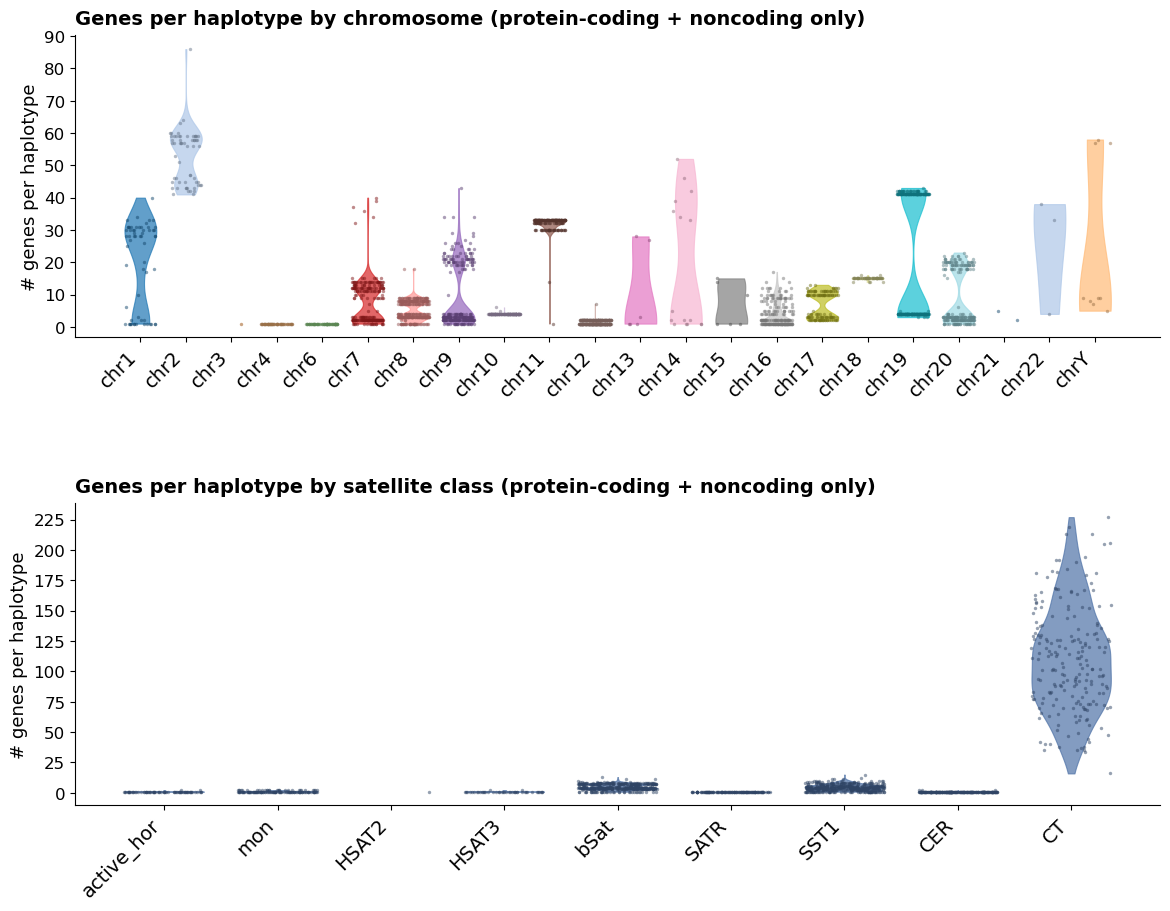

In [20]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

KEEP_BIOTYPES = ["protein-coding", "lncRNA", "other ncRNA"]
CHROM_ORDER   = [f"chr{i}" for i in list(range(1, 23)) + ["X", "Y"]]
SAT_ORDER     = [
    "active_hor", "hor", "dhor", "mixedAlpha", "mon",
    "HSAT1", "HSAT2", "HSAT3", "HSAT4", "HSAT5",
    "bSat", "gSat", "SATR", "SST1", "CER",
    "rDNA", "acrocentric", "CT", "other",
]

df_sub = df_filtered[df_filtered["biotype_class"].isin(KEEP_BIOTYPES)]

# sum across biotypes per haplotype per chrom
per_hap_chrom = (
    df_sub.groupby(["sample_id", "haplotype", "chrom"])
    .size()
    .reset_index(name="count")
)

per_hap_sat = (
    df_sub.groupby(["sample_id", "haplotype", "censat_category"])
    .size()
    .reset_index(name="count")
)

import matplotlib.cm as cm

# assign a color per chrom
chrom_colors = {
    chrom: cm.tab20(i % 20) for i, chrom in enumerate(CHROM_ORDER)
}

import matplotlib.colors as mcolors

import matplotlib.colors as mcolors
import matplotlib.cm as cm

chrom_colors = {chrom: cm.tab20(i % 20) for i, chrom in enumerate(CHROM_ORDER)}

def darken(color, factor=0.6):
    r, g, b, *a = mcolors.to_rgba(color)
    return (r * factor, g * factor, b * factor, 1)

def make_violin_panel(ax, data, x_col, x_order, title, color_map=None, default_color="#4E72A7"):
    valid = [c for c in x_order if c in data[x_col].unique()]
    for xi, cat in enumerate(valid):
        vals  = data[data[x_col] == cat]["count"].values
        color = color_map[cat] if color_map and cat in color_map else default_color
        if len(vals) >= 3:
            parts = ax.violinplot(vals, positions=[xi], widths=0.7,
                                  showextrema=False, showmedians=False)
            for pc in parts["bodies"]:
                pc.set_facecolor(color)
                pc.set_alpha(0.7)
                pc.set_edgecolor(color)
                pc.set_linewidth(0.8)

        if len(vals) > 0:
            dark   = darken(color)
            jitter = np.random.uniform(-0.35, 0.35, size=len(vals))
            ax.scatter(np.full(len(vals), xi) + jitter, vals,
                       color=dark, alpha=0.5, s=6, linewidths=0, zorder=6)

    ax.set_xticks(range(len(valid)))
    ax.set_xticklabels(valid, rotation=45, ha="right", fontsize=14)
    ax.set_title(title, fontsize=14, fontweight="bold", pad=8, loc="left")
    ax.set_ylabel("# genes per haplotype", fontsize=13)
    ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(axis="y", labelsize=12)



np.random.seed(42)
fig, axes = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={"hspace": 0.55})

make_violin_panel(axes[0], per_hap_chrom, "chrom", CHROM_ORDER,
                  "Genes per haplotype by chromosome (protein-coding + noncoding only)",
                  color_map=chrom_colors)
make_violin_panel(axes[1], per_hap_sat, "censat_category", SAT_ORDER,
                  "Genes per haplotype by satellite class (protein-coding + noncoding only)")

plt.show()



### Investigating chr19 two classes of haplotypes genes 

In [21]:
### Chr19 - investigating two classes of haplotypes 
# split chr19 haplotypes into two groups
chr19_counts = per_hap_chrom[per_hap_chrom["chrom"] == "chr19"]

low_haps  = chr19_counts[chr19_counts["count"] < 10][["sample_id", "haplotype"]]
high_haps = chr19_counts[chr19_counts["count"] > 30][["sample_id", "haplotype"]]

print(f"Low group  (<10 genes):  {len(low_haps)} haplotypes")
print(f"High group (>30 genes):  {len(high_haps)} haplotypes")

# get chr19 genes for each group
chr19_genes = df_sub[df_sub["chrom"] == "chr19"]

low_genes  = chr19_genes.merge(low_haps,  on=["sample_id", "haplotype"])
high_genes = chr19_genes.merge(high_haps, on=["sample_id", "haplotype"])

# count how many haplotypes each gene appears in per group
low_freq  = low_genes.groupby("gene_name")[["sample_id","haplotype"]].apply(
    lambda x: x.drop_duplicates().shape[0]).rename("n_low")
high_freq = high_genes.groupby("gene_name")[["sample_id","haplotype"]].apply(
    lambda x: x.drop_duplicates().shape[0]).rename("n_high")

gene_diff = pd.concat([high_freq, low_freq], axis=1).fillna(0).astype(int)
gene_diff["pct_high"] = 100 * gene_diff["n_high"] / len(high_haps)
gene_diff["pct_low"]  = 100 * gene_diff["n_low"]  / len(low_haps)
gene_diff["pct_diff"] = gene_diff["pct_high"] - gene_diff["pct_low"]

# genes enriched in high group
print("\nGenes found in high group but rare/absent in low group:")
display(
    gene_diff[gene_diff["pct_diff"] > 20]
    .sort_values("pct_diff", ascending=False)
    .merge(
        df_sub[df_sub["chrom"] == "chr19"][["gene_name", "gene_biotype", "censat_category"]]
        .drop_duplicates("gene_name"),
        on="gene_name", how="left"
    )
)

gene_diff_annot = gene_diff.merge(
    df_sub[df_sub["chrom"] == "chr19"][["gene_name", "gene_biotype", "censat_category"]]
    .drop_duplicates("gene_name"),
    on="gene_name", how="left"
)

print(f"Total genes on chr19: {len(gene_diff_annot)}")
print()

print("Enriched in HIGH group (pct_diff > 20):")
display(gene_diff_annot[gene_diff_annot["pct_diff"] > 20]
        .sort_values("pct_diff", ascending=False))

print("Enriched in LOW group (pct_diff < -20):")
display(gene_diff_annot[gene_diff_annot["pct_diff"] < -20]
        .sort_values("pct_diff", ascending=True))

print("Shared (present in both, |pct_diff| <= 20):")
display(gene_diff_annot[gene_diff_annot["pct_diff"].abs() <= 20]
        .sort_values("pct_high", ascending=False))



Low group  (<10 genes):  140 haplotypes
High group (>30 genes):  109 haplotypes

Genes found in high group but rare/absent in low group:


,gene_name,n_high,n_low,pct_high,pct_low,pct_diff,gene_biotype,censat_category
0,CCNYL6,109,0,100.0,0.000000,100.000000,lncRNA,CT
1,ERVK-28,109,0,100.0,0.000000,100.000000,lncRNA,CT
2,GOLGA2P9,109,0,100.0,0.000000,100.000000,lncRNA,CT
3,LINC00662,109,0,100.0,0.000000,100.000000,lncRNA,mon
4,LINC01233,109,0,100.0,0.000000,100.000000,lncRNA,CT
5,LINC01785,109,0,100.0,0.000000,100.000000,lncRNA,CT
6,LINC02987,109,0,100.0,0.000000,100.000000,lncRNA,CT
7,LINC03085,109,0,100.0,0.000000,100.000000,lncRNA,CT
8,RN7SL860P,109,0,100.0,0.000000,100.000000,misc_RNA,CT
9,RPSA2,109,0,100.0,0.000000,100.000000,protein_coding,CT


Total genes on chr19: 44

Enriched in HIGH group (pct_diff > 20):


,gene_name,n_high,n_low,pct_high,pct_low,pct_diff,gene_biotype,censat_category
1,CCNYL6,109,0,100.0,0.000000,100.000000,lncRNA,CT
2,ERVK-28,109,0,100.0,0.000000,100.000000,lncRNA,CT
3,GOLGA2P9,109,0,100.0,0.000000,100.000000,lncRNA,CT
4,LINC00662,109,0,100.0,0.000000,100.000000,lncRNA,mon
7,LINC01233,109,0,100.0,0.000000,100.000000,lncRNA,CT
8,LINC01785,109,0,100.0,0.000000,100.000000,lncRNA,CT
11,LINC02987,109,0,100.0,0.000000,100.000000,lncRNA,CT
12,LINC03085,109,0,100.0,0.000000,100.000000,lncRNA,CT
14,RN7SL860P,109,0,100.0,0.000000,100.000000,misc_RNA,CT
16,RPSA2,109,0,100.0,0.000000,100.000000,protein_coding,CT


Enriched in LOW group (pct_diff < -20):


,gene_name,n_high,n_low,pct_high,pct_low,pct_diff,gene_biotype,censat_category


Shared (present in both, |pct_diff| <= 20):


,gene_name,n_high,n_low,pct_high,pct_low,pct_diff,gene_biotype,censat_category
5,LINC00664,109,137,100.000000,97.857143,2.142857,lncRNA,bSat
6,LINC01224,109,140,100.000000,100.000000,0.000000,lncRNA,bSat
9,LINC01858,109,140,100.000000,100.000000,0.000000,lncRNA,bSat
10,LINC01859,109,140,100.000000,100.000000,0.000000,lncRNA,bSat
40,ZNF85,6,0,5.504587,0.000000,5.504587,protein_coding,CT
0,C8orf33,2,0,1.834862,0.000000,1.834862,protein_coding,CT
27,ZNF66,1,0,0.917431,0.000000,0.917431,protein_coding,CT


In [22]:
print("Low group (<10 genes):")
print(chr19_counts[chr19_counts["count"] < 10][["sample_id", "haplotype", "count"]].sort_values("count").to_string(index=False))

print("\nHigh group (>30 genes):")
print(chr19_counts[chr19_counts["count"] > 30][["sample_id", "haplotype", "count"]].sort_values("count", ascending=False).to_string(index=False))


Low group (<10 genes):
sample_id haplotype  count
  HG01993         2      3
  HG01993         1      3
  HG03453         1      3
  HG00408         1      4
  HG00438         2      4
    HG005         1      4
  HG00423         1      4
  HG00408         2      4
  HG00597         2      4
  HG00621         1      4
  HG00642         1      4
  HG00642         2      4
  HG00658         1      4
  HG00658         2      4
  HG00558         1      4
  HG00438         1      4
  HG00733         2      4
  HG00735         1      4
  HG00735         2      4
  HG00738         1      4
  HG00741         2      4
  HG01071         1      4
  HG01074         2      4
  HG01081         1      4
  HG01081         2      4
  HG01099         1      4
  HG01099         2      4
  HG01109         1      4
  HG01123         2      4
  HG01150         1      4
  HG00706         2      4
  HG00597         1      4
  HG01243         1      4
  HG01192         2      4
  HG01255         1      4
  HG0

/data/tmp/ipykernel_3585545/449148167.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  chr19_counts["haplotype"] = chr19_counts["haplotype"].astype(str)


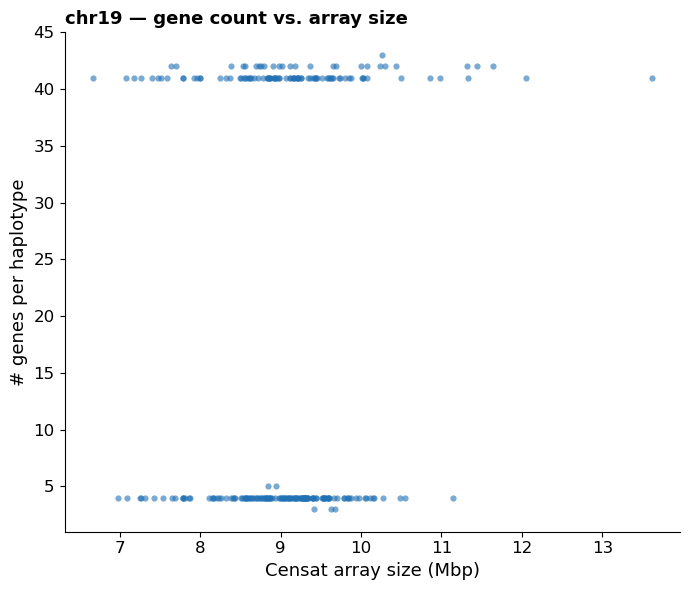

Pearson r=0.088  p=1.66e-01
Spearman ρ=0.048  p=4.47e-01


In [23]:
# get chr19 array sizes from regions_df
chr19_sizes = (
    regions_df[regions_df["chrom_assignment"] == "chr19"][["sample_id", "haplotype", "region_size_bp"]]
    .copy()
)
chr19_sizes["haplotype"]     = chr19_sizes["haplotype"].astype(str)
chr19_sizes["array_size_Mb"] = chr19_sizes["region_size_bp"] / 1e6

# merge with gene counts
chr19_counts["haplotype"] = chr19_counts["haplotype"].astype(str)
scatter_df = chr19_counts.merge(chr19_sizes, on=["sample_id", "haplotype"], how="inner")

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(scatter_df["array_size_Mb"], scatter_df["count"],
           alpha=0.6, s=20, color="#2171b5", linewidths=0)

ax.set_xlabel("Censat array size (Mbp)", fontsize=13)
ax.set_ylabel("# genes per haplotype", fontsize=13)
ax.set_title("chr19 — gene count vs. array size", fontsize=13, fontweight="bold", loc="left")
ax.spines[["top", "right"]].set_visible(False)
ax.tick_params(labelsize=12)
plt.tight_layout()
plt.show()

# print correlation
from scipy.stats import pearsonr, spearmanr
r, p   = pearsonr(scatter_df["array_size_Mb"], scatter_df["count"])
rho, p2 = spearmanr(scatter_df["array_size_Mb"], scatter_df["count"])
print(f"Pearson r={r:.3f}  p={p:.2e}")
print(f"Spearman ρ={rho:.3f}  p={p2:.2e}")


In [24]:
bed_path = bed_map[('HG00408', '1')]
import subprocess
result = subprocess.run(['grep', '-c', 'HG00408#1#', bed_path], capture_output=True, text=True)
print("HG00408#1# count:", result.stdout.strip())
result2 = subprocess.run(['grep', '-c', 'HG00408#2#', bed_path], capture_output=True, text=True)
print("HG00408#2# count:", result2.stdout.strip())


HG00408#1# count: 0
HG00408#2# count: 2639


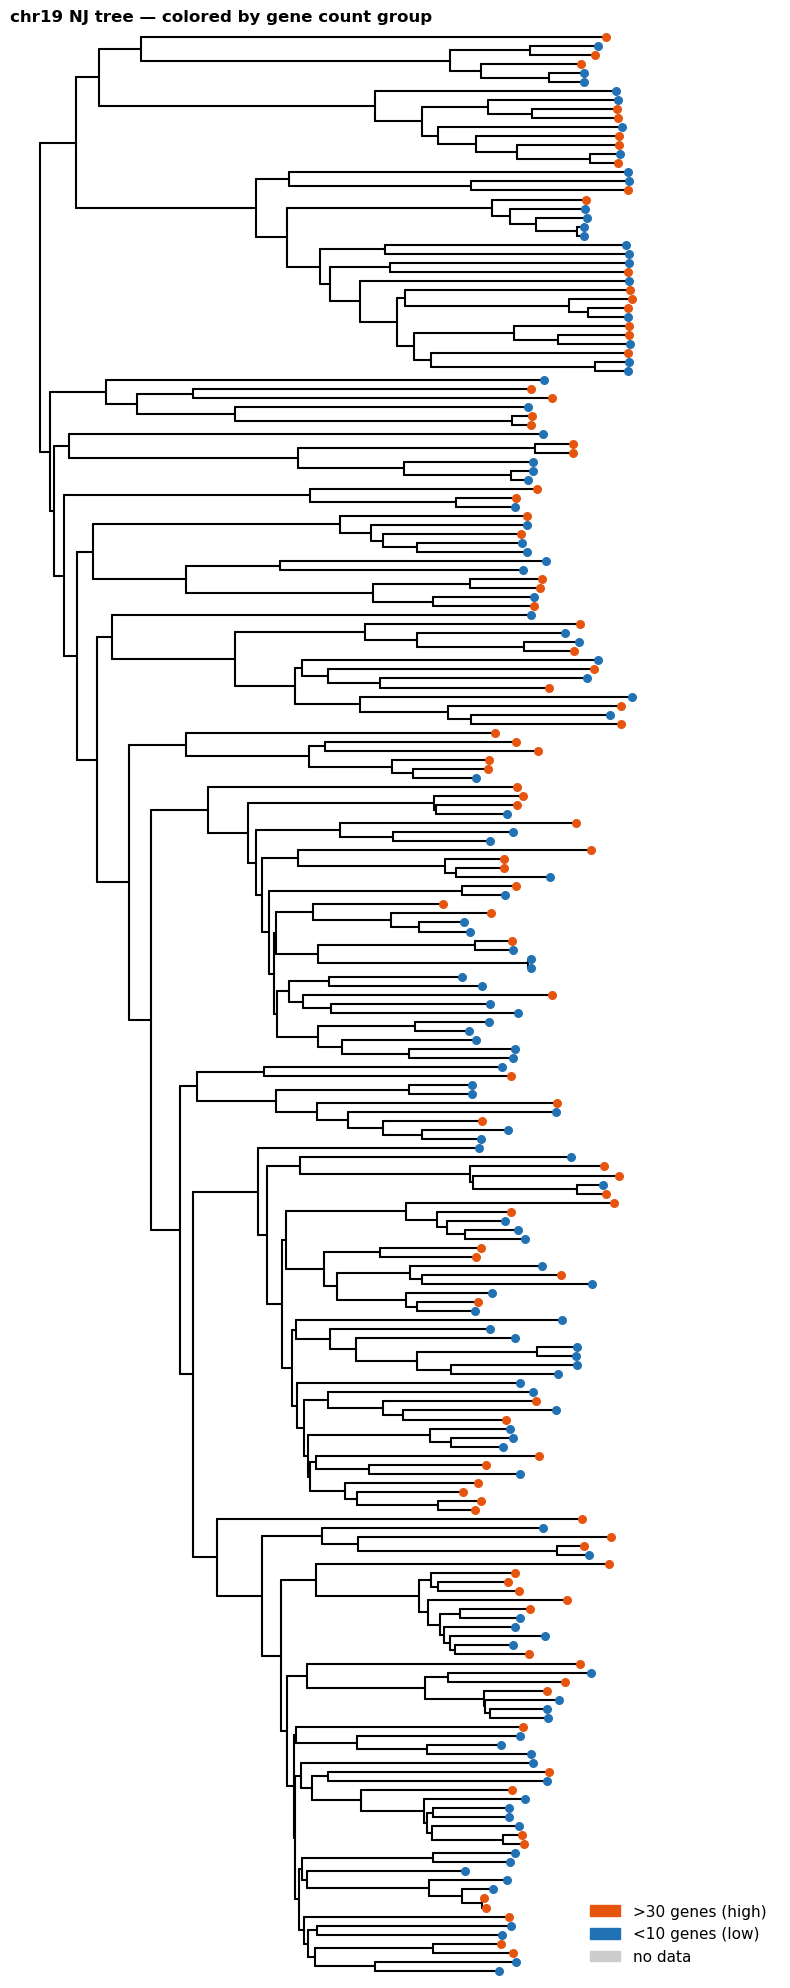

In [25]:
import sys
!{sys.executable} -m pip install biopython --quiet
from Bio import Phylo
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# build label → group mapping from chr19_counts
label_to_group = {}
for _, row in chr19_counts.iterrows():
    label = f"{row['sample_id']}.{row['haplotype']}"
    if row["count"] < 10:
        label_to_group[label] = "low"
    elif row["count"] > 30:
        label_to_group[label] = "high"

GROUP_COLORS = {
    "low":  "#2171b5",
    "high": "#e6550d",
    None:   "#cccccc",
}

tree_path = "/private/groups/patenlab/mira/centrolign/batch_submissions/centrolign/release2_QC_v2/all_pairs/nj_trees/chr19_r2_QC_v2_centrolign_all_pairs_nj_tree.format5.nwk"
tree = Phylo.read(tree_path, "newick")

# prune to QC samples only
qc_labels = set(
    f"{row['sample_id']}.{row['haplotype']}"
    for _, row in chr19_counts.iterrows()
)
leaves_to_remove = [leaf for leaf in tree.get_terminals() if leaf.name not in qc_labels]
for leaf in leaves_to_remove:
    tree.prune(leaf)

tree.ladderize()

# compute layout before drawing
depths  = tree.depths()
leaf_y  = {leaf.name: i + 1 for i, leaf in enumerate(tree.get_terminals())}

fig, ax = plt.subplots(figsize=(8, 20))
Phylo.draw(tree, axes=ax,
           label_func=lambda c: "",
           do_show=False,
           branch_labels=lambda c: None)

# overlay colored dots at leaf tips
for leaf in tree.get_terminals():
    grp   = label_to_group.get(leaf.name)
    color = GROUP_COLORS.get(grp, GROUP_COLORS[None])
    ax.scatter(depths[leaf], leaf_y[leaf.name],
               color=color, s=30, zorder=5, clip_on=False)

ax.set_title("chr19 NJ tree — colored by gene count group",
             fontsize=12, fontweight="bold", loc="left")
ax.axis("off")

handles = [
    mpatches.Patch(color=GROUP_COLORS["high"], label=">30 genes (high)"),
    mpatches.Patch(color=GROUP_COLORS["low"],  label="<10 genes (low)"),
    mpatches.Patch(color=GROUP_COLORS[None],   label="no data"),
]
ax.legend(handles=handles, loc="lower right", frameon=False, fontsize=11)
plt.tight_layout()
plt.show()



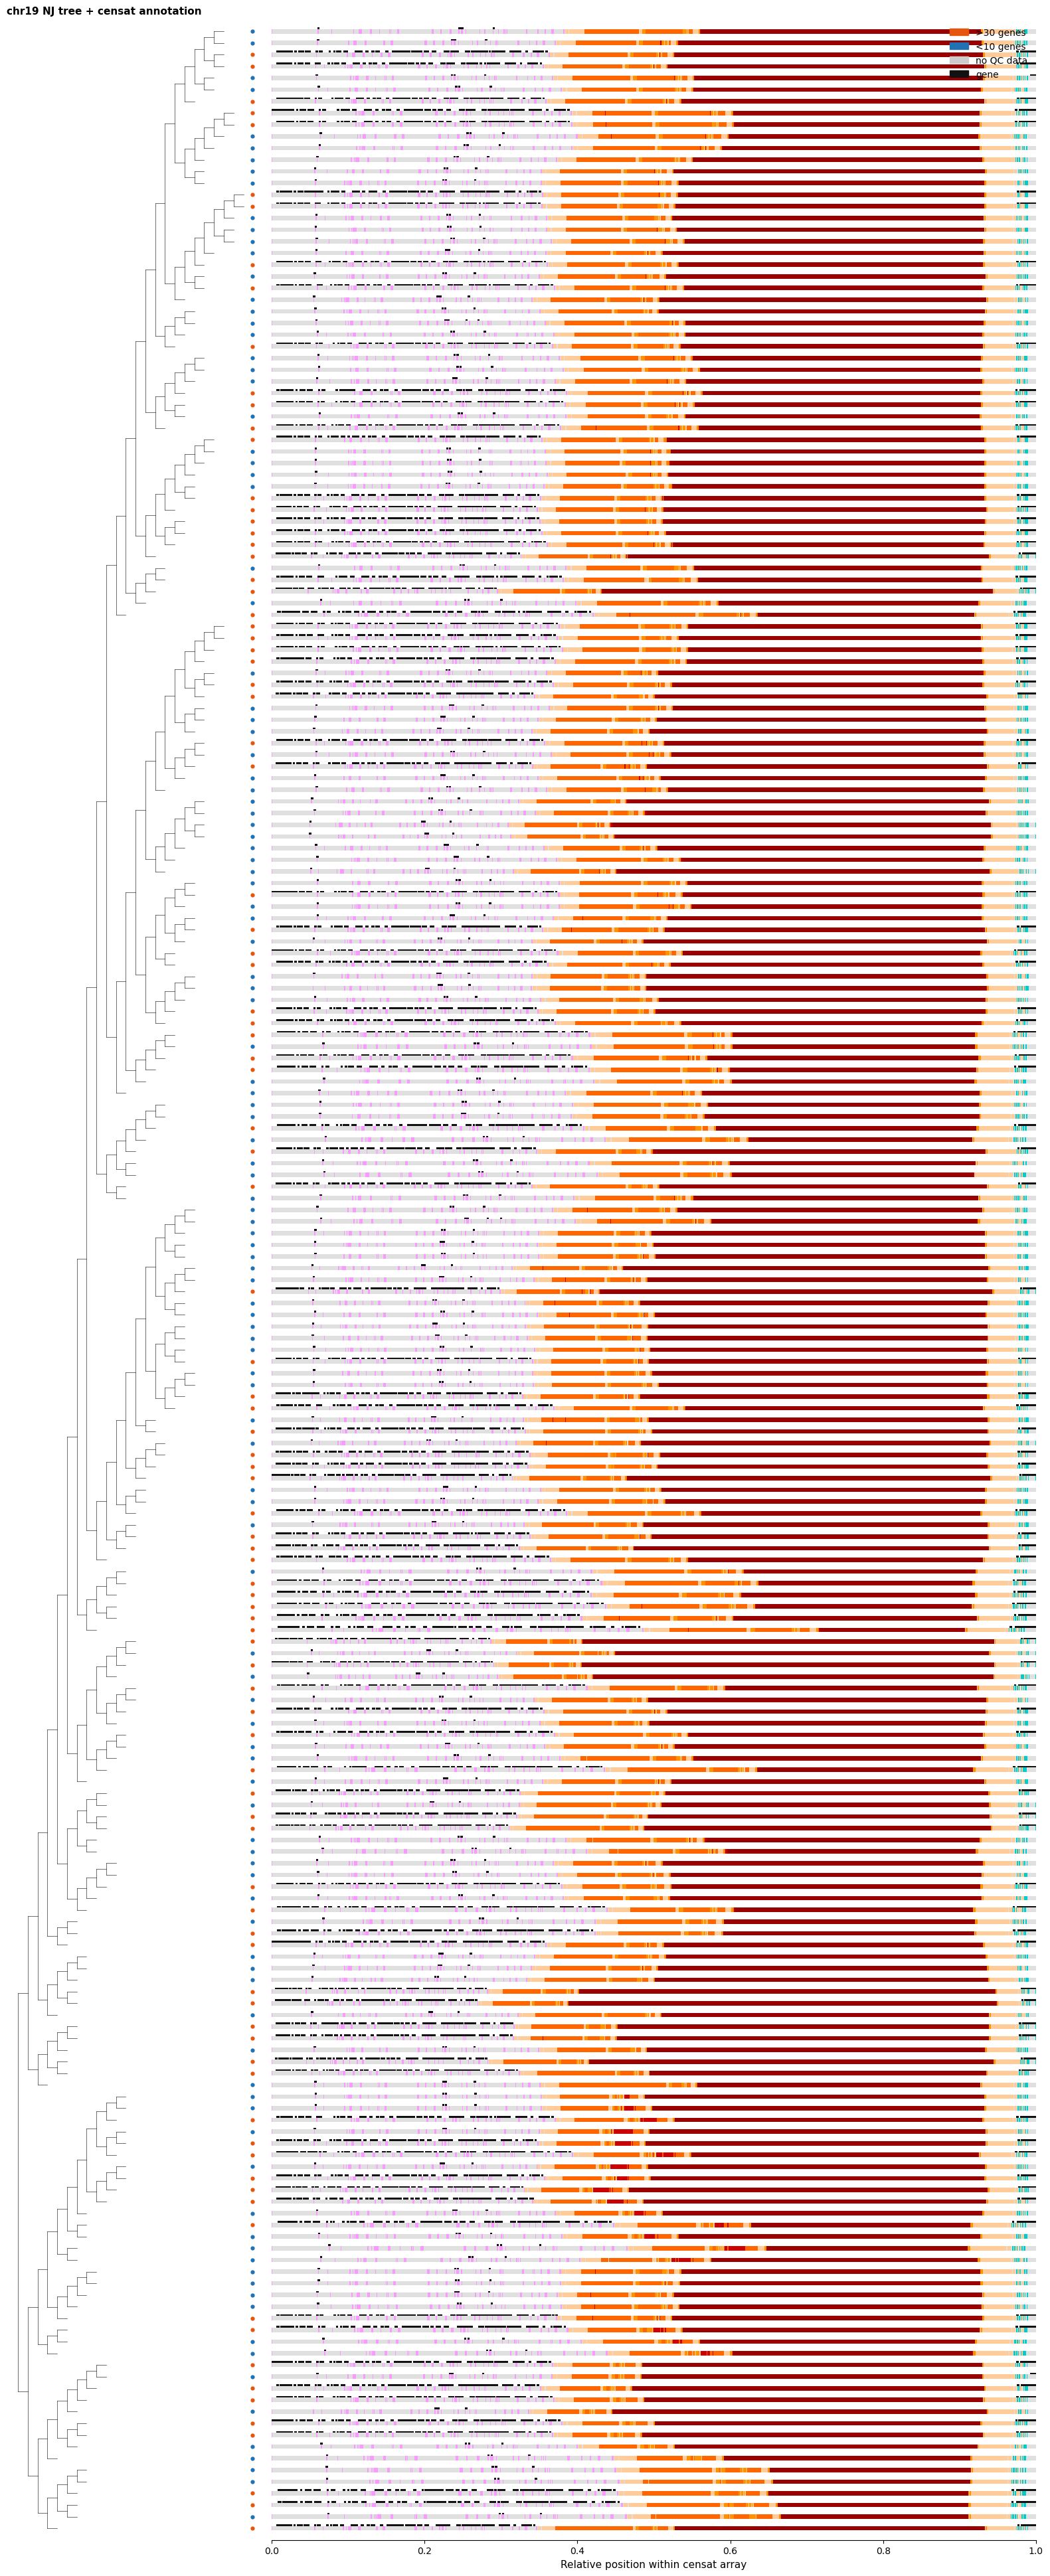

In [26]:
import sys, os, glob, re
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from Bio import Phylo

CENSAT_BED_DIR = '/private/groups/migalab/juklucas/censat_regions/censat_beds'
CHROM = "chr19"

GROUP_COLORS = {"low": "#2171b5", "high": "#e6550d", None: "#cccccc"}

label_to_group = {}
for _, row in chr19_counts.iterrows():
    label = f"{row['sample_id']}.{row['haplotype']}"
    if row["count"] < 10:   label_to_group[label] = "low"
    elif row["count"] > 30: label_to_group[label] = "high"

# ── load + prune tree ─────────────────────────────────────────────────────────
tree_path = "/private/groups/patenlab/mira/centrolign/batch_submissions/centrolign/release2_QC_v2/all_pairs/nj_trees/chr19_r2_QC_v2_centrolign_all_pairs_nj_tree.format5.nwk"
tree = Phylo.read(tree_path, "newick")
qc_labels = set(f"{r['sample_id']}.{r['haplotype']}" for _, r in chr19_counts.iterrows())
for leaf in [l for l in tree.get_terminals() if l.name not in qc_labels]:
    tree.prune(leaf)
tree.ladderize()

# ── cladogram drawing (all leaves at x=1) ────────────────────────────────────
def draw_cladogram(tree, ax):
    terminals = tree.get_terminals()
    clade_y   = {id(leaf): i for i, leaf in enumerate(terminals)}

    def assign_y(clade):
        if clade.is_terminal():
            return clade_y[id(clade)]
        ys = [assign_y(c) for c in clade.clades]
        y  = sum(ys) / len(ys)
        clade_y[id(clade)] = y
        return y
    assign_y(tree.root)

    depths    = tree.depths(unit_branch_lengths=True)
    max_depth = max(depths.values())
    clade_x   = {id(c): depths[c] / max_depth for c in tree.find_clades()}

    for clade in tree.find_clades(order='level'):
        x = clade_x[id(clade)]
        y = clade_y[id(clade)]
        if clade.clades:
            child_ys = [clade_y[id(c)] for c in clade.clades]
            ax.plot([x, x], [min(child_ys), max(child_ys)], 'k-', lw=0.4)
            for child in clade.clades:
                ax.plot([x, clade_x[id(child)]], [clade_y[id(child)]] * 2, 'k-', lw=0.4)

    return {leaf.name: clade_y[id(leaf)] for leaf in terminals}

# ── bed map ───────────────────────────────────────────────────────────────────
bed_map = {}
for bed_path in glob.glob(f'{CENSAT_BED_DIR}/*.cenSat.bed'):
    fname    = os.path.basename(bed_path)
    parts    = fname.replace('.cenSat.bed', '').split('_')
    sid      = parts[0]
    hap_raw  = parts[1]
    hap      = hap_raw.replace('hap','').replace('mat','2').replace('pat','1')
    bed_map[(sid, hap)] = bed_path

# ── censat regions for chr19 ──────────────────────────────────────────────────
chr19_regions = regions_df[
    (regions_df['chrom_assignment'] == CHROM) & (regions_df['pass_qc'] == True)
].copy()
chr19_regions['haplotype'] = chr19_regions['haplotype'].astype(str)
region_idx = {(r['sample_id'], r['haplotype']): r for _, r in chr19_regions.iterrows()}

chr19_genes_df = df_filtered[df_filtered['chrom'] == CHROM].copy()
chr19_genes_df['haplotype'] = chr19_genes_df['haplotype'].astype(str)

def load_censat(sample_id, haplotype, region):
    bed_path = bed_map.get((sample_id, haplotype))
    if bed_path is None:
        return []
    seq   = region['sequence_id'].split('#')[-1]
    rs, re_ = region['region_start'], region['region_end']
    size  = re_ - rs
    rows  = []
    with open(bed_path) as f:
        for line in f:
            if line.startswith('track'): continue
            cols = line.strip().split('\t')
            if len(cols) < 9: continue
            s_parts = cols[0].split('#')
            s = s_parts[2] if len(s_parts) == 3 else cols[0]
            if s != seq: continue
            start, end = int(cols[1]), int(cols[2])
            if end < rs or start > re_: continue
            start, end = max(start, rs), min(end, re_)
            try: color = tuple(int(x)/255 for x in cols[8].split(','))
            except: color = (0.5, 0.5, 0.5)
            rows.append({
                'ns': (start - rs) / size,
                'ne': (end   - rs) / size,
                'color': color,
            })
    return rows

# ── figure ────────────────────────────────────────────────────────────────────
terminals = tree.get_terminals()
n         = len(terminals)
ROW_H     = 0.22
fig = plt.figure(figsize=(20, n * ROW_H + 2))
gs  = gridspec.GridSpec(1, 2, width_ratios=[1, 3], wspace=0.02)
ax_tree = fig.add_subplot(gs[0])
ax_ann  = fig.add_subplot(gs[1])

leaf_y = draw_cladogram(tree, ax_tree)
ax_tree.set_xlim(-0.05, 1.08)
ax_tree.set_ylim(-1, n)
ax_tree.axis('off')

CSAT_H = 0.38
GENE_H = 0.15

for leaf in terminals:
    yi          = leaf_y[leaf.name]
    sid, hap    = leaf.name.rsplit('.', 1)
    grp         = label_to_group.get(leaf.name)
    dot_color   = GROUP_COLORS.get(grp, GROUP_COLORS[None])
    ax_tree.scatter(1.04, yi, color=dot_color, s=12, zorder=5, clip_on=False)

    region = region_idx.get((sid, hap))
    if region is None:
        continue

    # censat track
    for seg in load_censat(sid, hap, region):
        ax_ann.add_patch(mpatches.Rectangle(
            (seg['ns'], yi - CSAT_H / 2), seg['ne'] - seg['ns'], CSAT_H,
            color=seg['color'], linewidth=0
        ))

    # gene track (above censat bar)
    rs, re_ = region['region_start'], region['region_end']
    size    = re_ - rs
    genes   = chr19_genes_df[(chr19_genes_df['sample_id'] == sid) &
                              (chr19_genes_df['haplotype'] == hap)]
    for _, g in genes.iterrows():
        gs_ = max(0, min(1, (g['start'] - rs) / size))
        ge_ = max(0, min(1, (g['end']   - rs) / size))
        ax_ann.add_patch(mpatches.Rectangle(
            (gs_, yi + CSAT_H / 2), max(ge_ - gs_, 0.003), GENE_H,
            color='#111111', linewidth=0
        ))

ax_ann.set_xlim(0, 1)
ax_ann.set_ylim(-1, n)
ax_ann.set_xlabel("Relative position within censat array", fontsize=11)
ax_ann.set_yticks([])
ax_ann.spines[['top', 'right', 'left']].set_visible(False)
ax_ann.tick_params(axis='x', labelsize=10)

handles = [
    mpatches.Patch(color=GROUP_COLORS["high"], label=">30 genes"),
    mpatches.Patch(color=GROUP_COLORS["low"],  label="<10 genes"),
    mpatches.Patch(color=GROUP_COLORS[None],   label="no QC data"),
    mpatches.Patch(color='#111111',            label="gene"),
]
ax_ann.legend(handles=handles, loc='upper right', frameon=False, fontsize=10)
ax_tree.set_title("chr19 NJ tree + censat annotation", fontsize=11, fontweight="bold", loc="left")

#plt.savefig('/private/groups/patenlab/mira/chr19_tree_censat.png', dpi=150, bbox_inches='tight')
plt.show()


### Exploring bimodal types of genes for all chroms 

In [27]:
def bimodal_gene_analysis(chrom, low_thresh, high_thresh):
    counts = per_hap_chrom[per_hap_chrom["chrom"] == chrom]
    low_haps  = counts[counts["count"] <  low_thresh][["sample_id", "haplotype"]]
    high_haps = counts[counts["count"] > high_thresh][["sample_id", "haplotype"]]

    print(f"\n{'='*60}")
    print(f"{chrom}  |  Low (<{low_thresh}): {len(low_haps)} haps  |  High (>{high_thresh}): {len(high_haps)} haps")
    print(f"{'='*60}")

    if len(low_haps) == 0 or len(high_haps) == 0:
        print("  Skipping: one group is empty.")
        return

    chrom_genes = df_sub[df_sub["chrom"] == chrom]
    low_genes   = chrom_genes.merge(low_haps,  on=["sample_id", "haplotype"])
    high_genes  = chrom_genes.merge(high_haps, on=["sample_id", "haplotype"])

    low_freq  = low_genes.groupby("gene_name")[["sample_id","haplotype"]].apply(
        lambda x: x.drop_duplicates().shape[0]).rename("n_low")
    high_freq = high_genes.groupby("gene_name")[["sample_id","haplotype"]].apply(
        lambda x: x.drop_duplicates().shape[0]).rename("n_high")

    gene_diff = pd.concat([high_freq, low_freq], axis=1).fillna(0).astype(int)
    gene_diff["pct_high"] = 100 * gene_diff["n_high"] / len(high_haps)
    gene_diff["pct_low"]  = 100 * gene_diff["n_low"]  / len(low_haps)
    gene_diff["pct_diff"] = gene_diff["pct_high"] - gene_diff["pct_low"]

    annot_cols = (chrom_genes[["gene_name", "gene_biotype", "censat_category"]]
                  .drop_duplicates("gene_name"))
    gene_diff_annot = gene_diff.merge(annot_cols, on="gene_name", how="left")

    print(f"Total genes on {chrom}: {len(gene_diff_annot)}")

    print(f"\nEnriched in HIGH group (pct_diff > 20):")
    display(gene_diff_annot[gene_diff_annot["pct_diff"] > 20]
            .sort_values("pct_diff", ascending=False))

    print(f"Enriched in LOW group (pct_diff < -20):")
    display(gene_diff_annot[gene_diff_annot["pct_diff"] < -20]
            .sort_values("pct_diff", ascending=True))

    print(f"Shared (|pct_diff| <= 20):")
    display(gene_diff_annot[gene_diff_annot["pct_diff"].abs() <= 20]
            .sort_values("pct_high", ascending=False))


CHROM_THRESHOLDS = [
    ("chr1",  10, 20),
    ("chr2",  50, 50),
    ("chr7",  10, 10),
    ("chr9",  10, 10),
    ("chr14", 10, 30),
    ("chr19", 10, 30),
    ("chr20", 10, 15),
]

for chrom, lo, hi in CHROM_THRESHOLDS:
    bimodal_gene_analysis(chrom, lo, hi)



chr1  |  Low (<10): 19 haps  |  High (>20): 36 haps
Total genes on chr1: 35

Enriched in HIGH group (pct_diff > 20):


,gene_name,n_high,n_low,pct_high,pct_low,pct_diff,gene_biotype,censat_category
0,FAM72C,36,0,100.000000,0.000000,100.000000,protein_coding,CT
2,H3-7,36,0,100.000000,0.000000,100.000000,protein_coding,CT
5,LINC02591,36,0,100.000000,0.000000,100.000000,lncRNA,CT
29,RNVU1-26,36,0,100.000000,0.000000,100.000000,snRNA,CT
25,RNVU1-15,36,0,100.000000,0.000000,100.000000,snRNA,CT
26,RNVU1-17,36,0,100.000000,0.000000,100.000000,snRNA,CT
27,RNVU1-18,36,0,100.000000,0.000000,100.000000,snRNA,CT
28,RNVU1-23,36,0,100.000000,0.000000,100.000000,snRNA,CT
19,RNU1-114P,36,0,100.000000,0.000000,100.000000,snRNA,CT
20,RNU1-143P,36,0,100.000000,0.000000,100.000000,snRNA,CT


Enriched in LOW group (pct_diff < -20):


,gene_name,n_high,n_low,pct_high,pct_low,pct_diff,gene_biotype,censat_category
12,MIR8078,14,18,38.888889,94.736842,-55.847953,miRNA,bSat


Shared (|pct_diff| <= 20):


...

,gene_name,n_high,n_low,pct_high,pct_low,pct_diff,gene_biotype,censat_category
0,5_8S_rRNA,80,0,100.0,0.000000,100.000000,rRNA,CT
3,FAM242A,80,0,100.0,0.000000,100.000000,lncRNA,CT
5,FRG1BP,80,0,100.0,0.000000,100.000000,lncRNA,CT
9,MIR4477B,80,0,100.0,0.000000,100.000000,miRNA,CT
8,MIR4477A,80,0,100.0,0.000000,100.000000,miRNA,CT
7,LINC01733,80,0,100.0,0.000000,100.000000,lncRNA,CT
18,U6,80,0,100.0,0.000000,100.000000,snRNA,CT
12,MIR663B,80,0,100.0,0.000000,100.000000,miRNA,CT
19,Y_RNA,80,0,100.0,0.000000,100.000000,misc_RNA,CT
11,MIR663AHG,80,0,100.0,0.000000,100.000000,lncRNA,CT


Enriched in LOW group (pct_diff < -20):


,gene_name,n_high,n_low,pct_high,pct_low,pct_diff,gene_biotype,censat_category


Shared (|pct_diff| <= 20):


,gene_name,n_high,n_low,pct_high,pct_low,pct_diff,gene_biotype,censat_category
6,LINC01597,80,134,100.00,99.259259,0.740741,lncRNA,SST1
16,TTTY7B,28,53,35.00,39.259259,-4.259259,lncRNA,SST1
15,TTTY7,23,31,28.75,22.962963,5.787037,lncRNA,SST1
14,TTTY13,21,47,26.25,34.814815,-8.564815,lncRNA,SST1
13,TTTY1,9,14,11.25,10.370370,0.879630,lncRNA,SST1
17,TTTY8,3,3,3.75,2.222222,1.527778,lncRNA,SST1
20,TTTY1B,0,2,0.00,1.481481,-1.481481,lncRNA,SST1


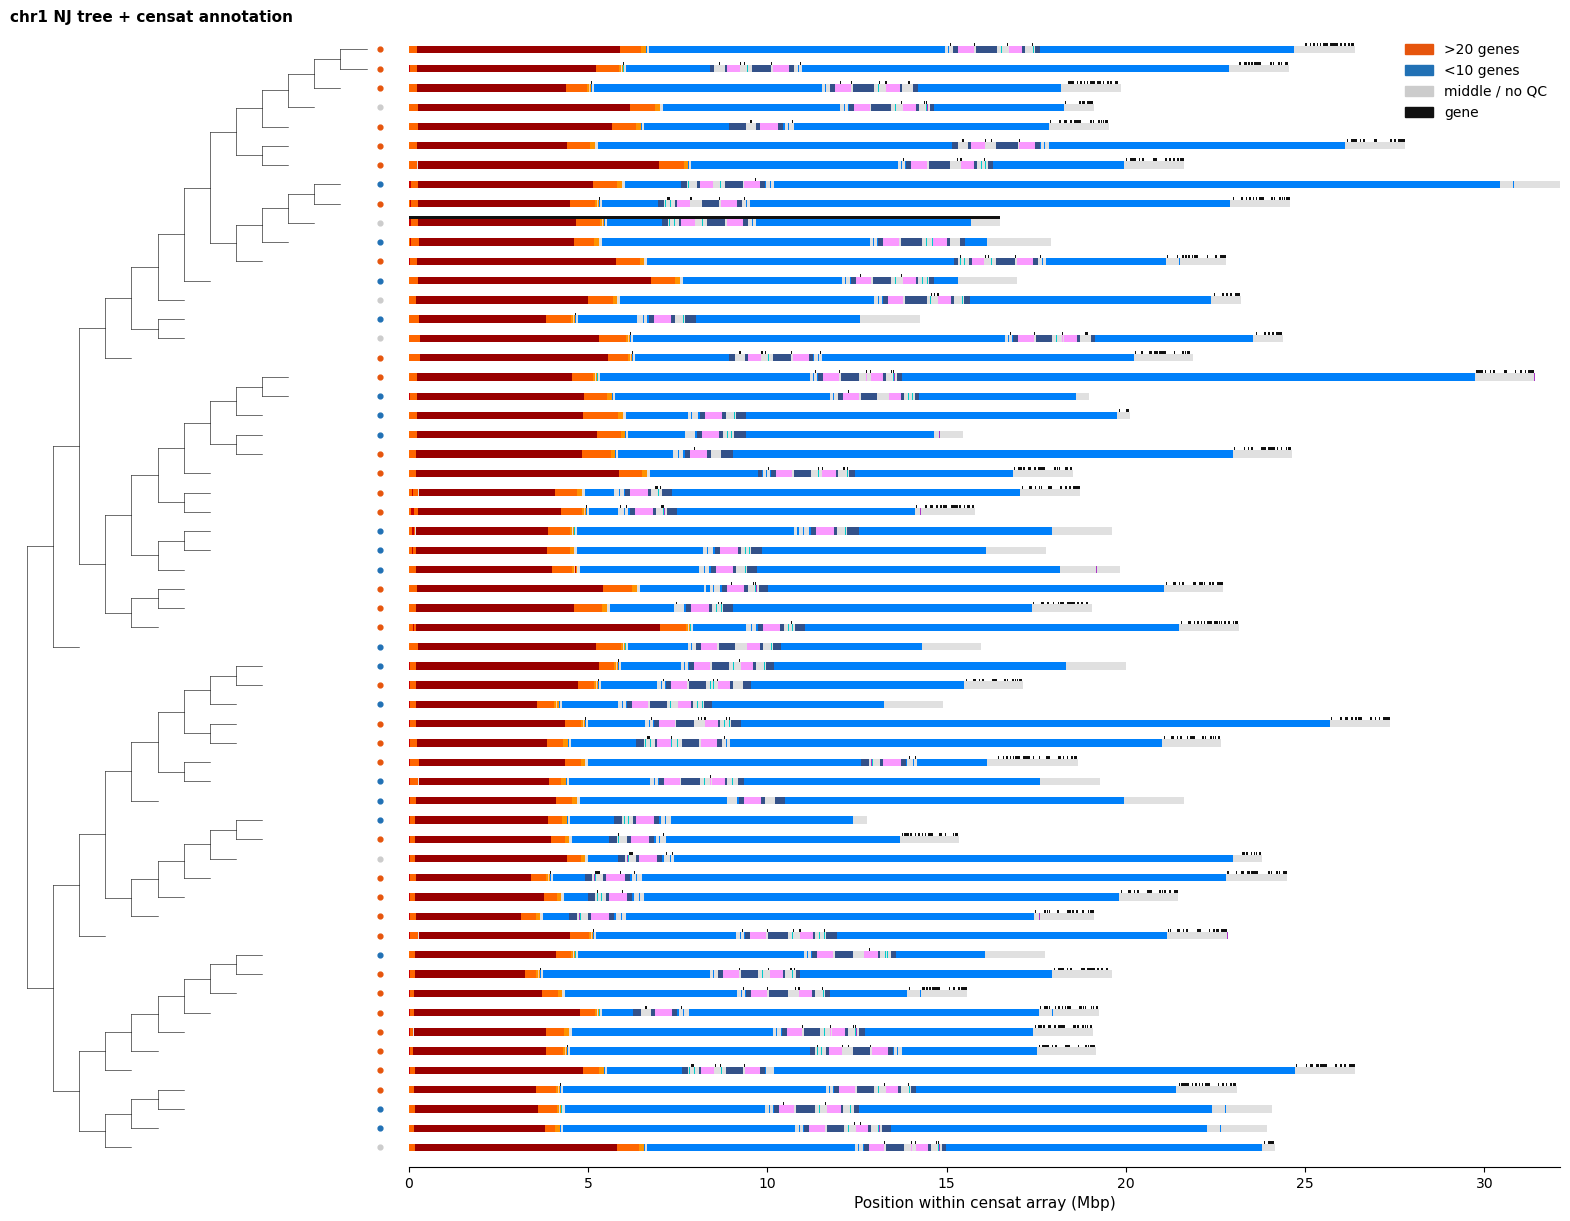

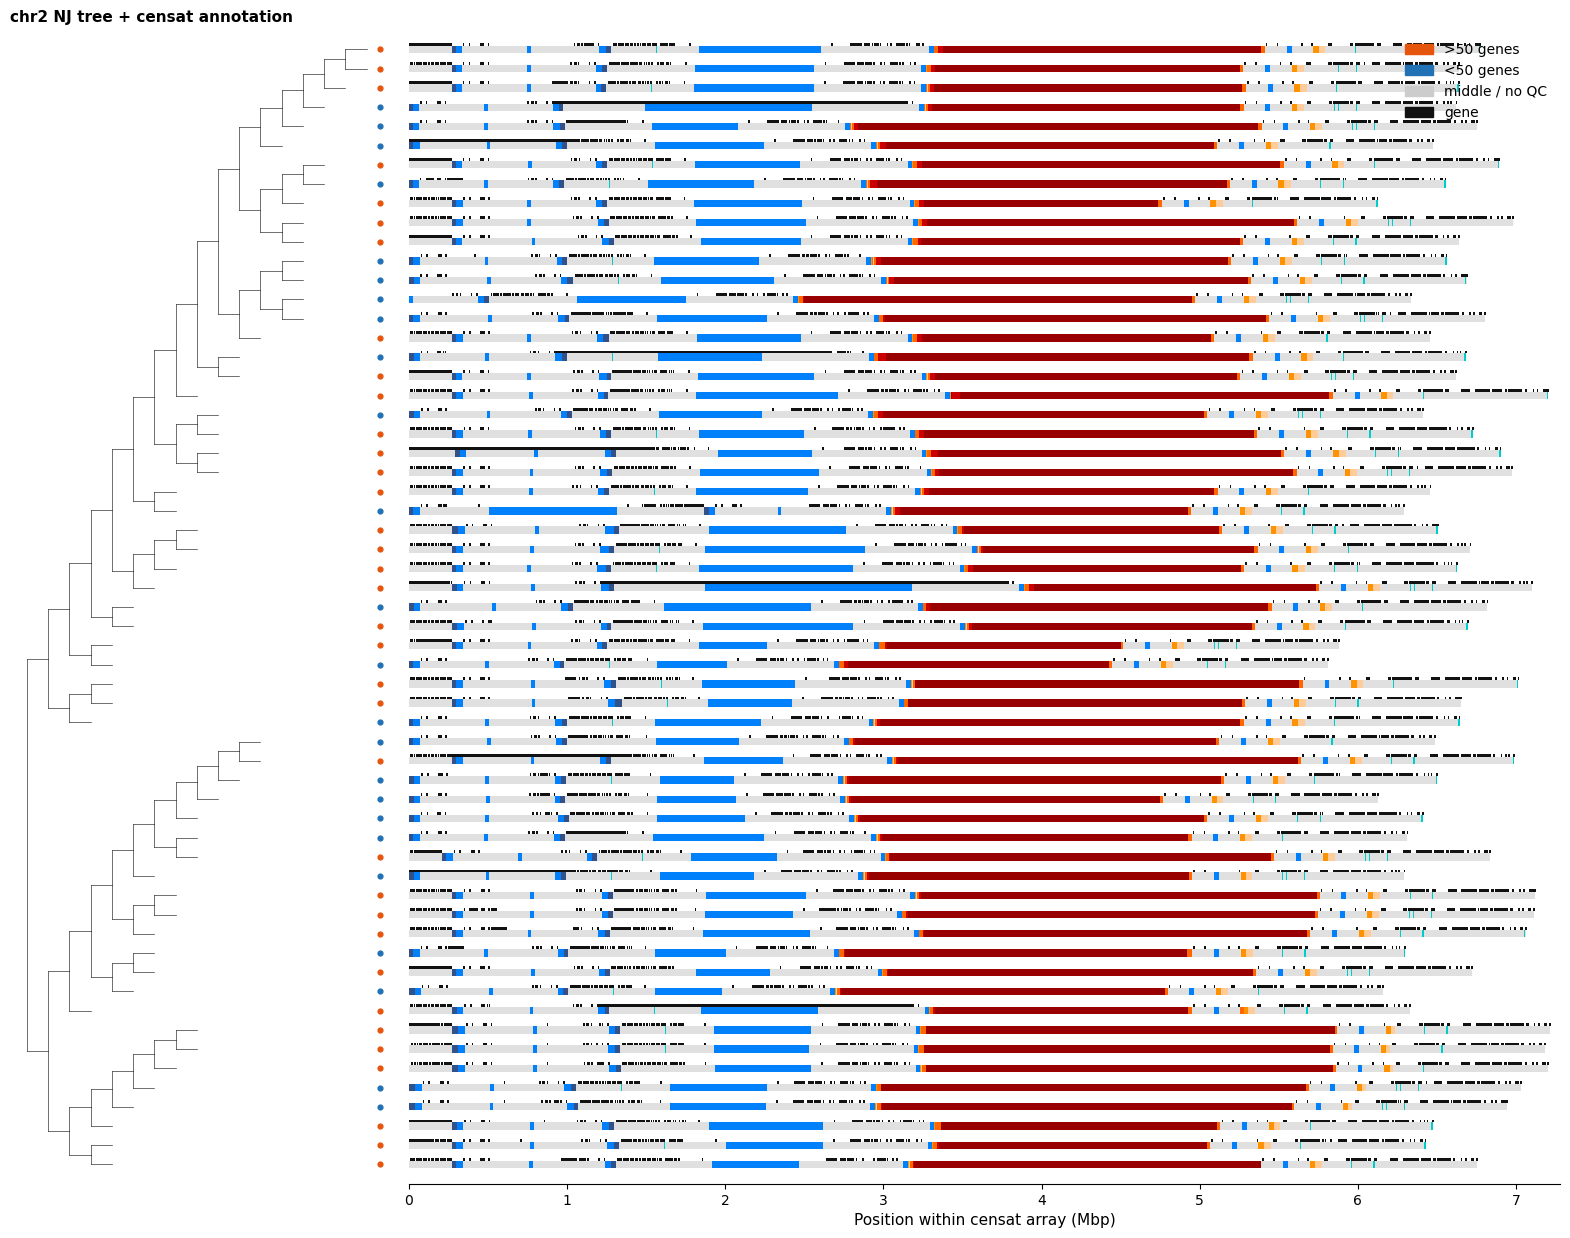

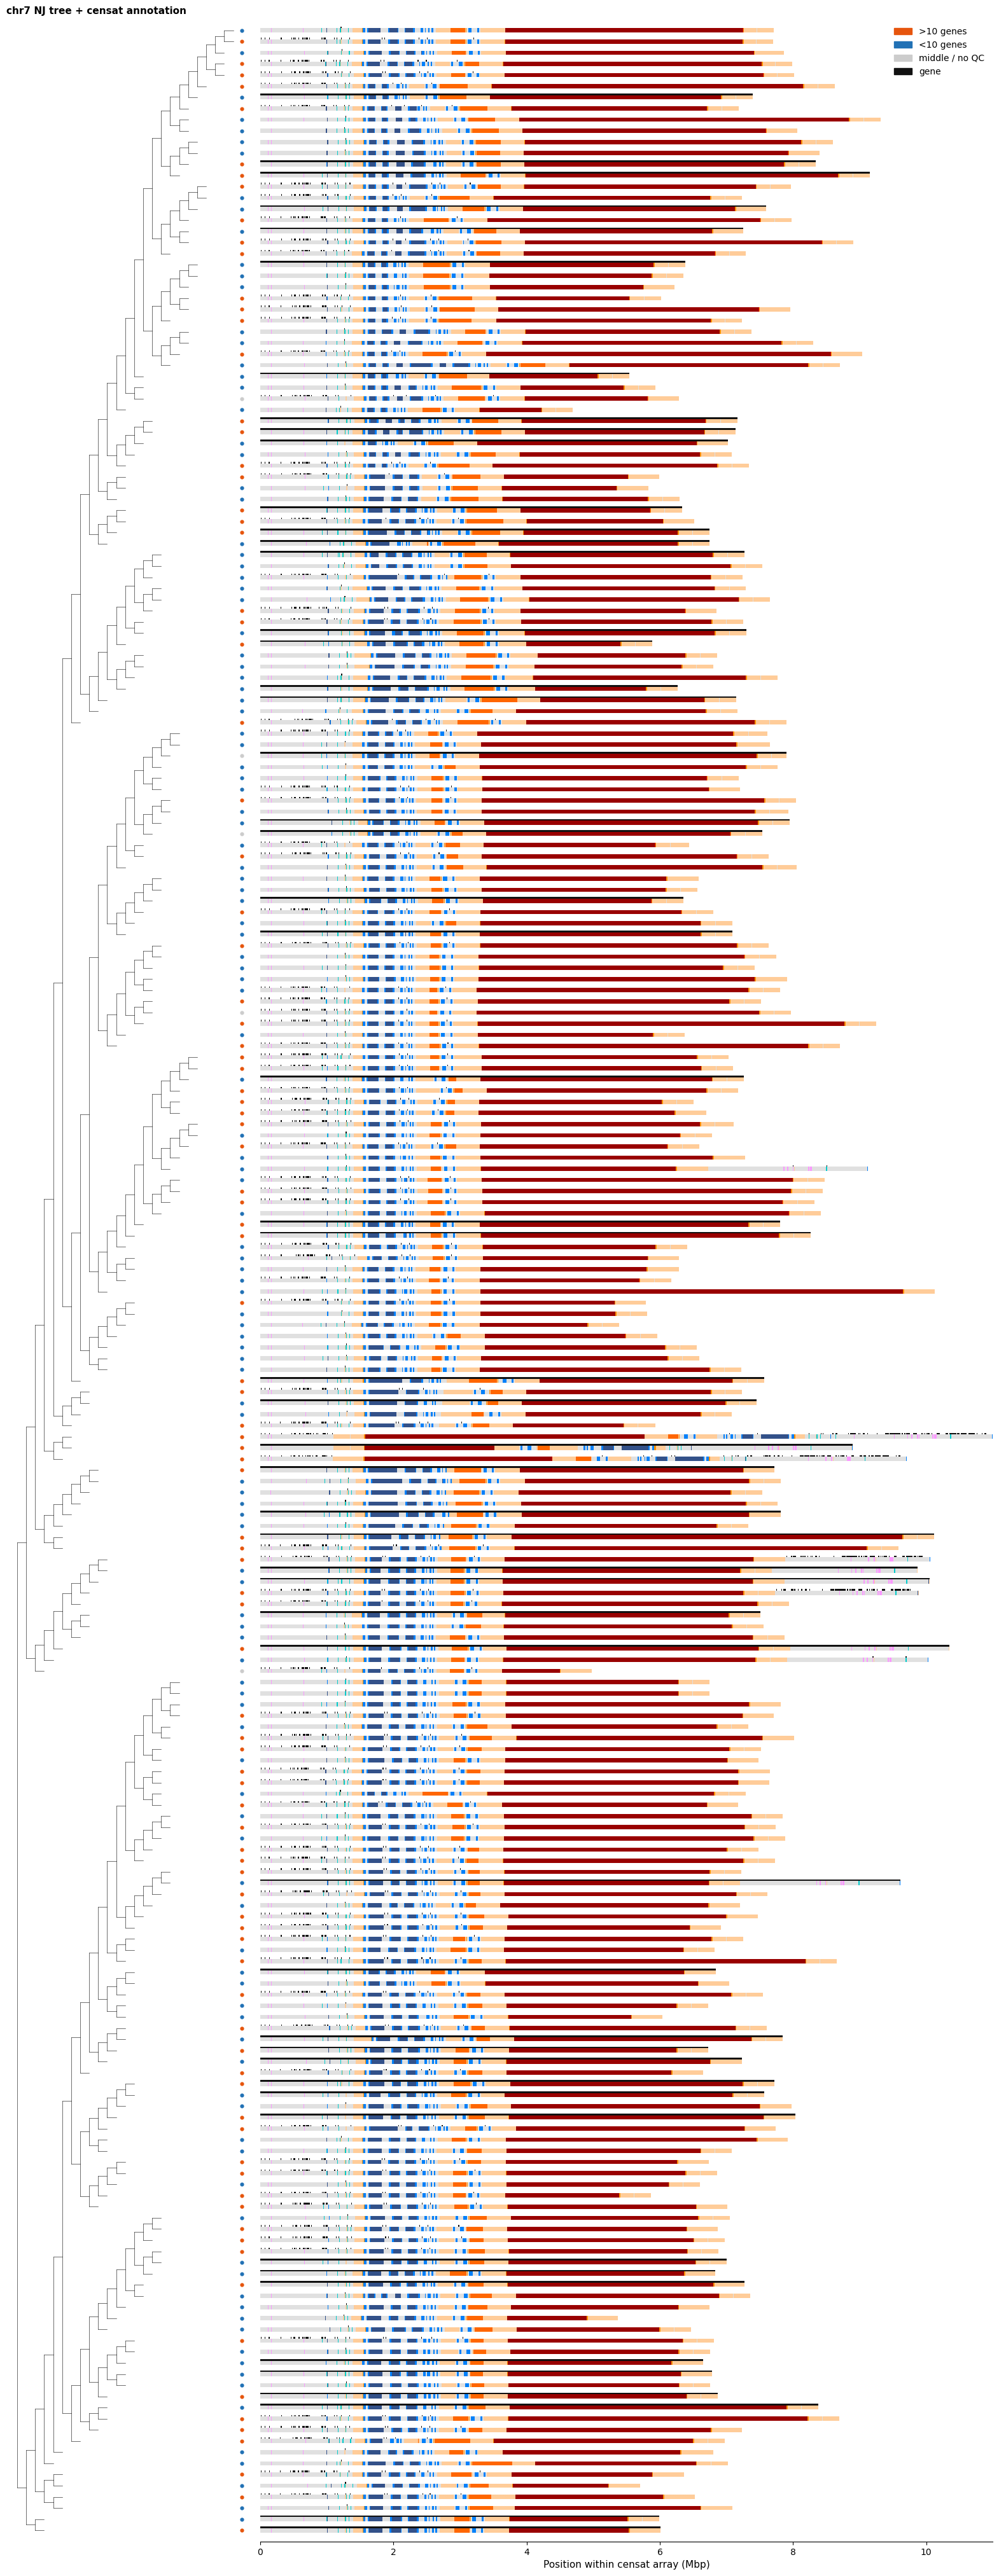

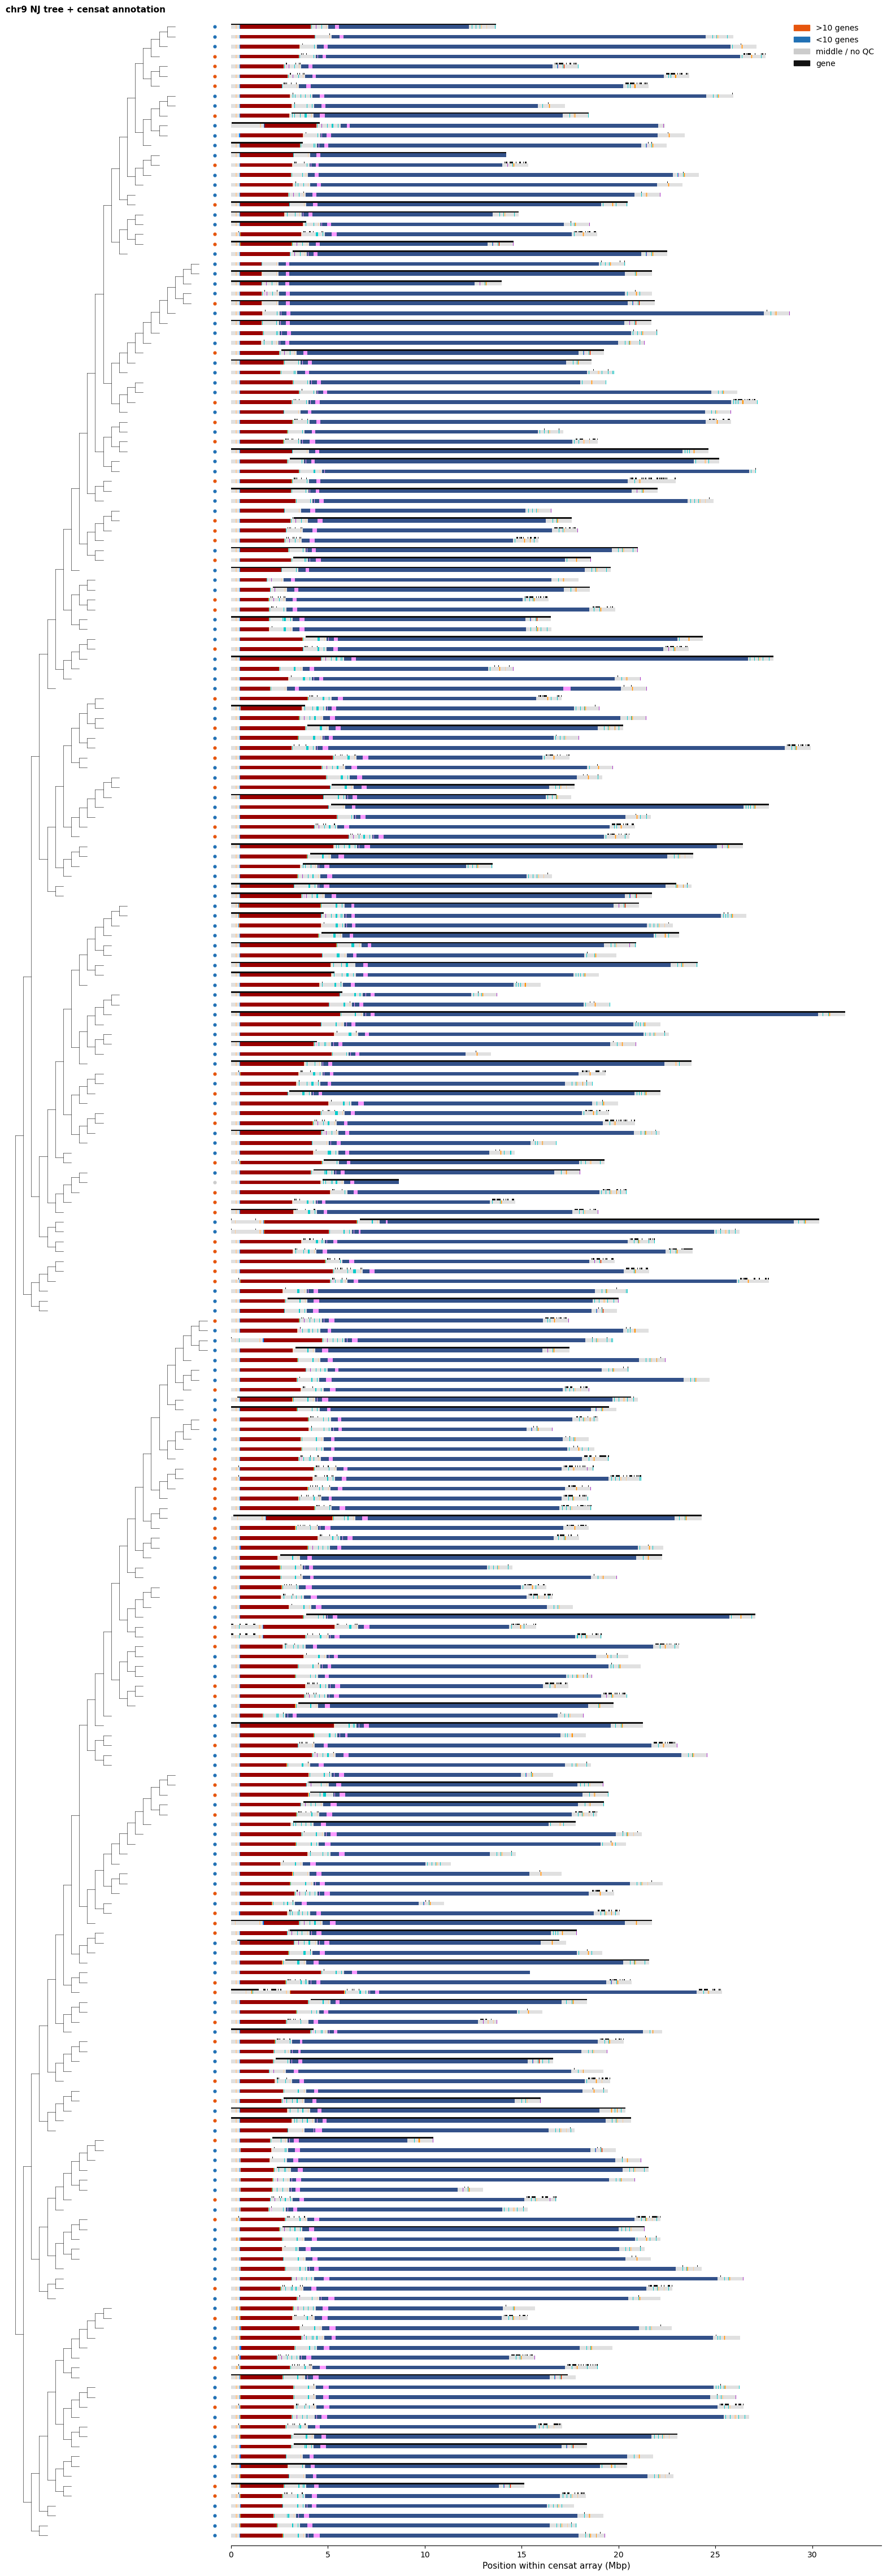

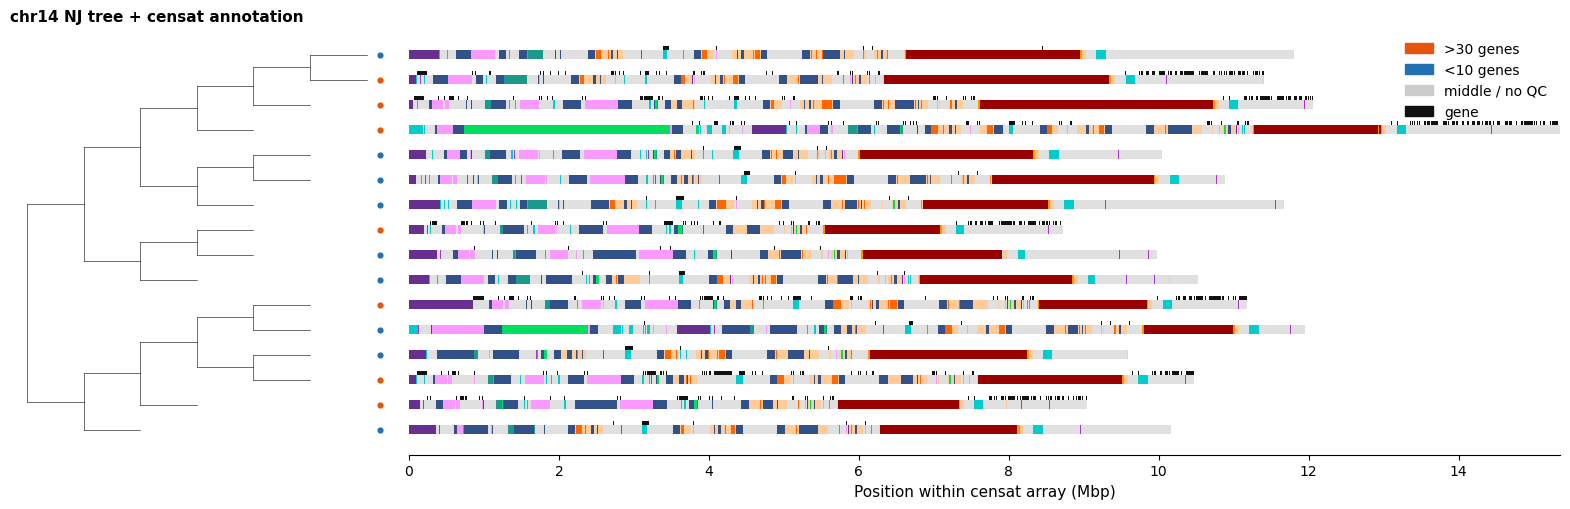

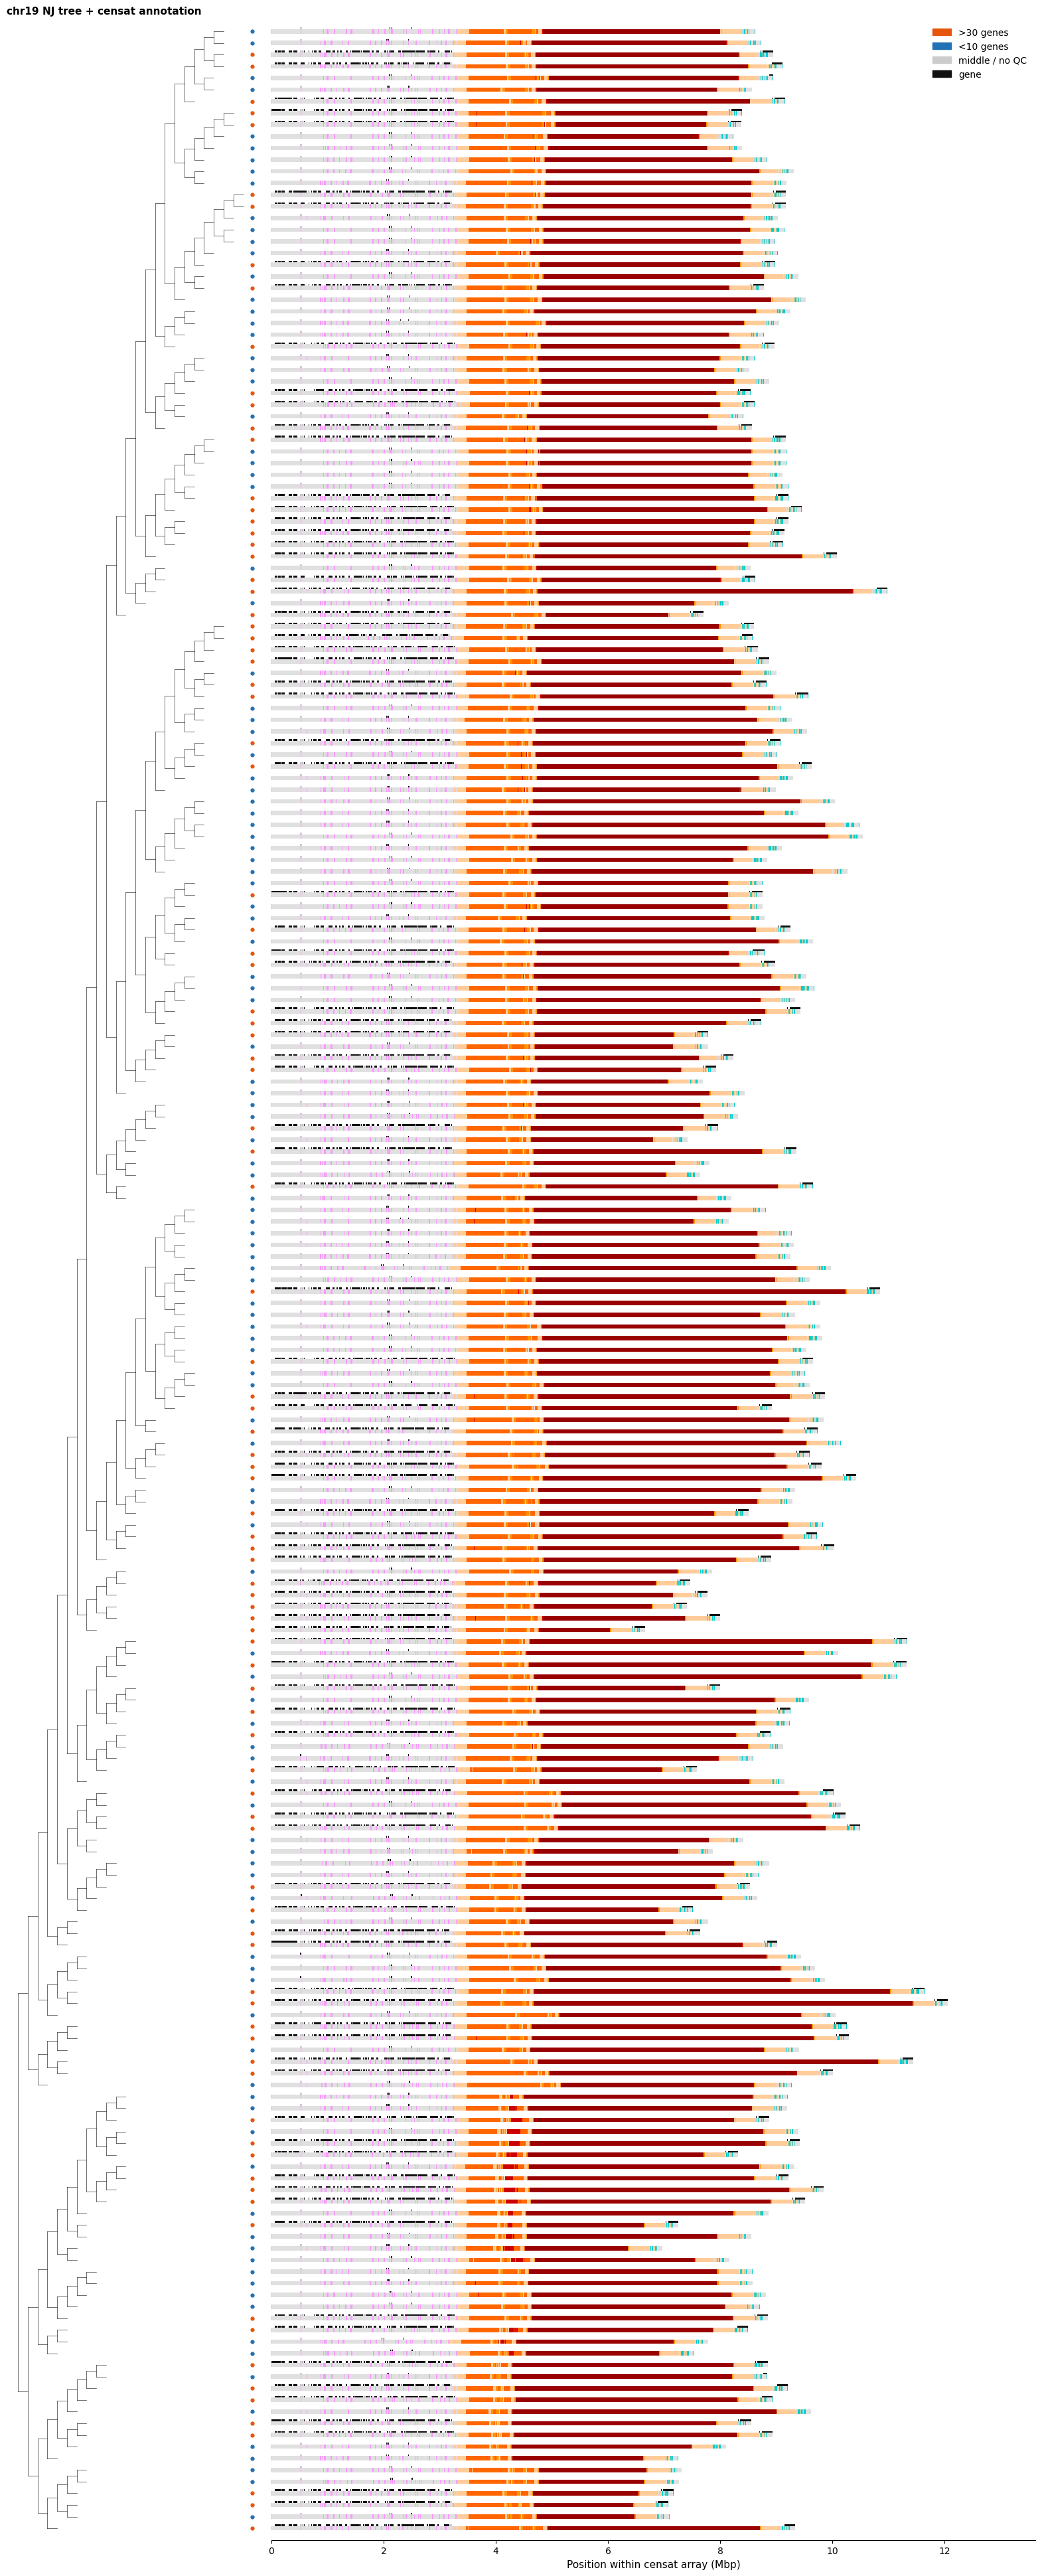

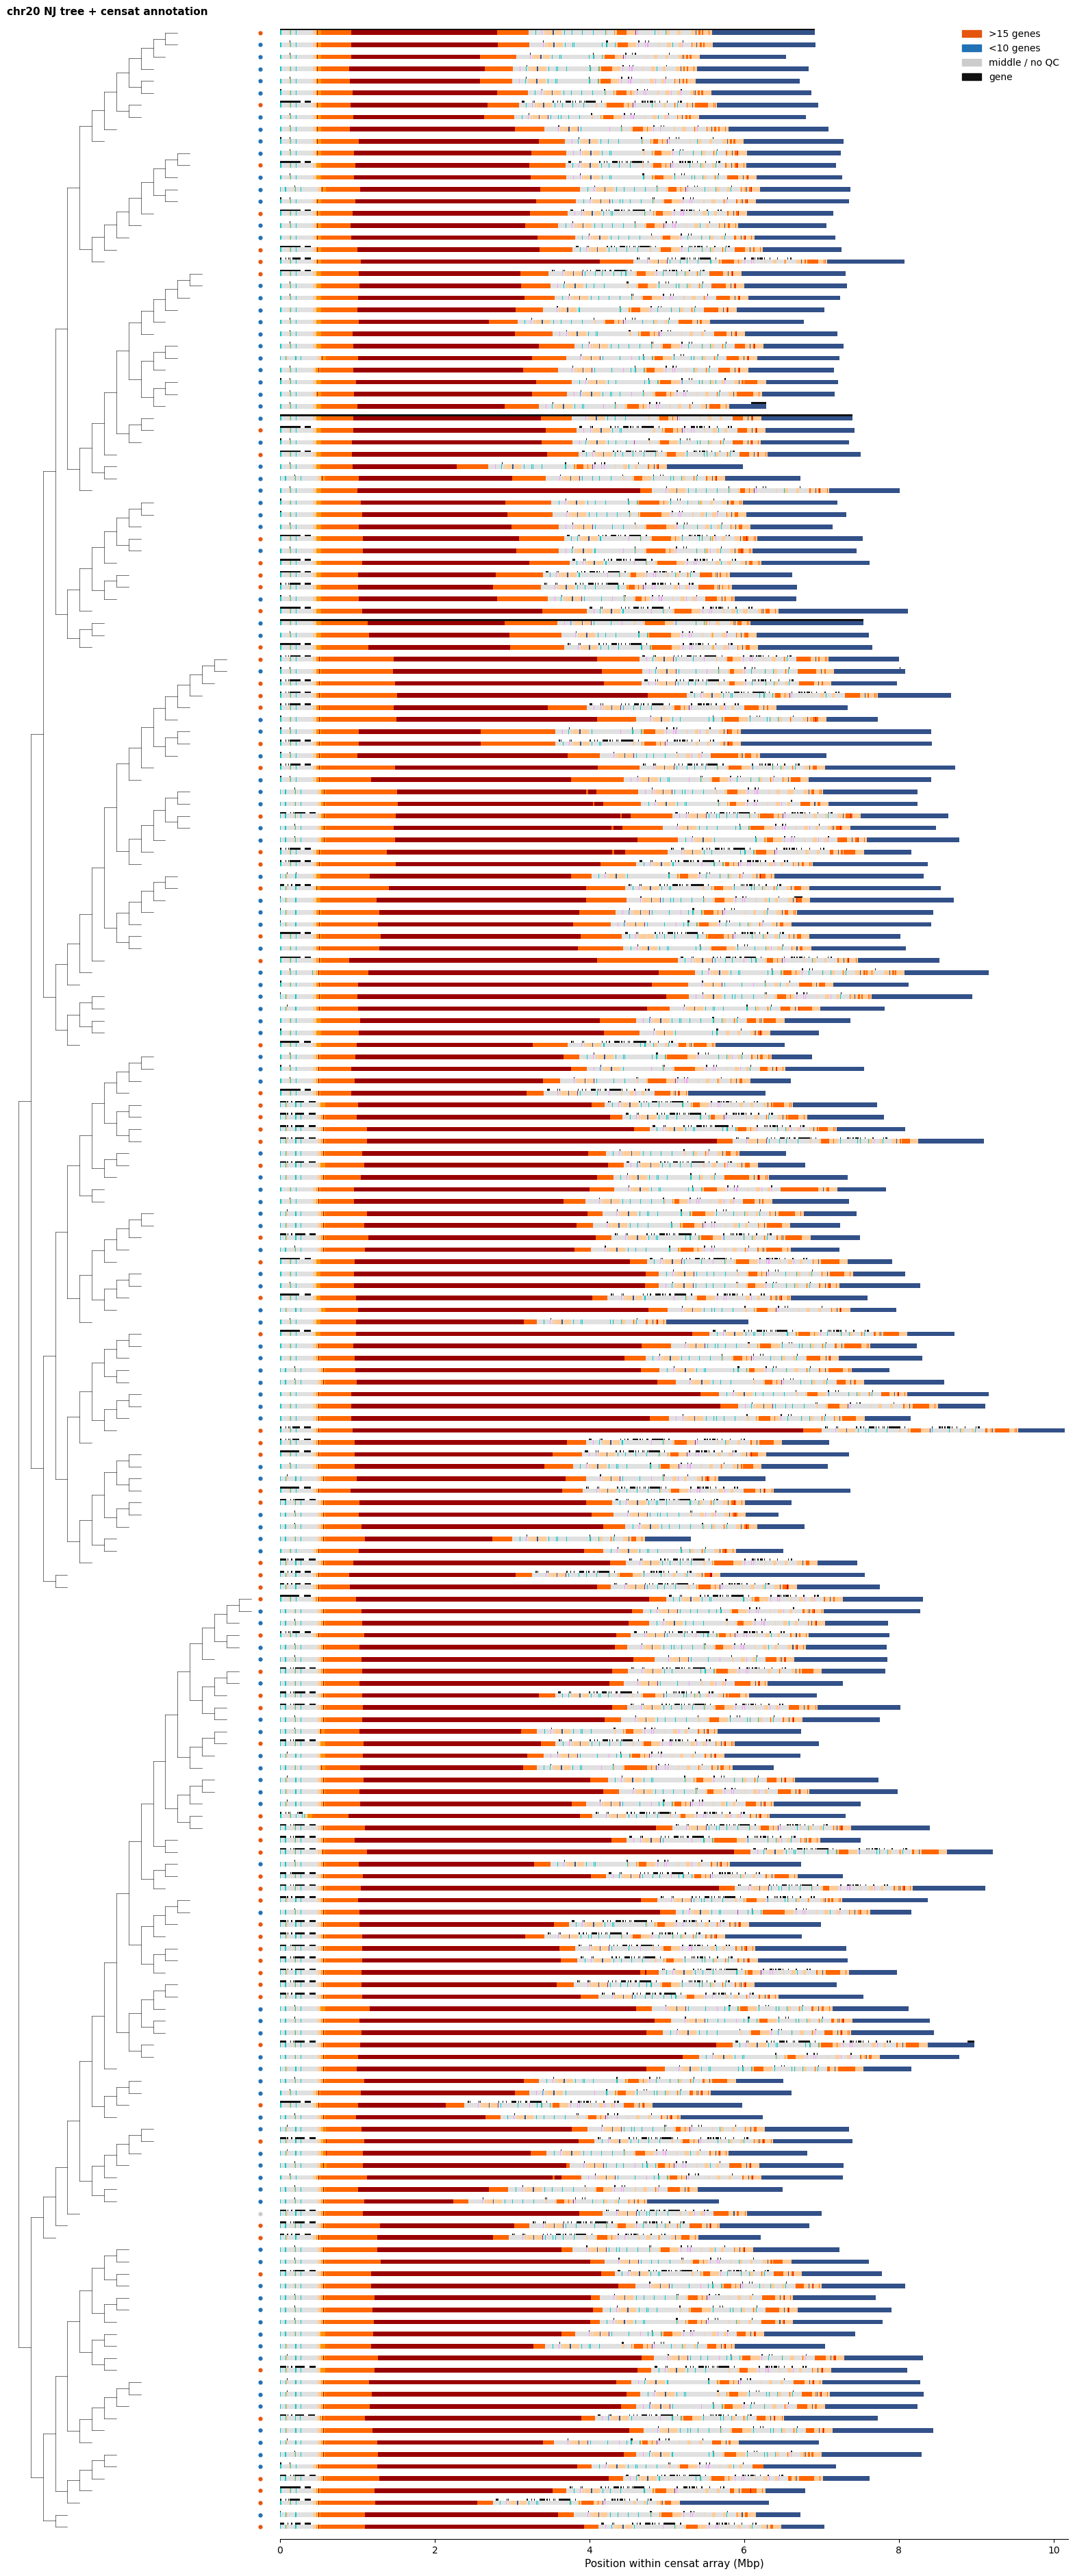

In [28]:
import sys, os, glob
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from Bio import Phylo

CENSAT_BED_DIR = '/private/groups/migalab/juklucas/censat_regions/censat_beds'
TREE_DIR       = '/private/groups/patenlab/mira/centrolign/batch_submissions/centrolign/release2_QC_v2/all_pairs/nj_trees'
GROUP_COLORS   = {"low": "#2171b5", "high": "#e6550d", None: "#cccccc"}

# ── shared setup (run once) ───────────────────────────────────────────────────
bed_map = {}
for bed_path in glob.glob(f'{CENSAT_BED_DIR}/*.cenSat.bed'):
    fname   = os.path.basename(bed_path)
    parts   = fname.replace('.cenSat.bed', '').split('_')
    sid     = parts[0]
    hap_raw = parts[1]
    hap     = hap_raw.replace('hap', '').replace('mat', '2').replace('pat', '1')
    bed_map[(sid, hap)] = bed_path

def draw_cladogram(tree, ax):
    terminals = tree.get_terminals()
    clade_y   = {id(leaf): i for i, leaf in enumerate(terminals)}
    def assign_y(clade):
        if clade.is_terminal(): return clade_y[id(clade)]
        ys = [assign_y(c) for c in clade.clades]
        y  = sum(ys) / len(ys)
        clade_y[id(clade)] = y
        return y
    assign_y(tree.root)
    depths    = tree.depths(unit_branch_lengths=True)
    max_depth = max(depths.values())
    clade_x   = {id(c): depths[c] / max_depth for c in tree.find_clades()}
    for clade in tree.find_clades(order='level'):
        x = clade_x[id(clade)]
        y = clade_y[id(clade)]
        if clade.clades:
            child_ys = [clade_y[id(c)] for c in clade.clades]
            ax.plot([x, x], [min(child_ys), max(child_ys)], 'k-', lw=0.4)
            for child in clade.clades:
                ax.plot([x, clade_x[id(child)]], [clade_y[id(child)]] * 2, 'k-', lw=0.4)
    return {leaf.name: clade_y[id(leaf)] for leaf in terminals}

def load_censat(sample_id, haplotype, region):
    """Returns segments with start/end as Mbp offset from region start."""
    bed_path = bed_map.get((sample_id, haplotype))
    if bed_path is None: return []
    seq     = region['sequence_id'].split('#')[-1]
    rs, re_ = region['region_start'], region['region_end']
    rows    = []
    with open(bed_path) as f:
        for line in f:
            if line.startswith('track'): continue
            cols = line.strip().split('\t')
            if len(cols) < 9: continue
            s_parts = cols[0].split('#')
            s = s_parts[2] if len(s_parts) == 3 else cols[0]
            if s != seq: continue
            start, end = int(cols[1]), int(cols[2])
            if end < rs or start > re_: continue
            start, end = max(start, rs), min(end, re_)
            try:    color = tuple(int(x) / 255 for x in cols[8].split(','))
            except: color = (0.5, 0.5, 0.5)
            rows.append({
                'start': (start - rs) / 1e6,
                'end':   (end   - rs) / 1e6,
                'color': color,
            })
    return rows

# ── per-chrom plot function ───────────────────────────────────────────────────
def plot_chrom_tree(chrom, low_thresh, high_thresh, save_path=None):
    tree_path = f'{TREE_DIR}/{chrom}_r2_QC_v2_centrolign_all_pairs_nj_tree.format5.nwk'
    if not os.path.exists(tree_path):
        print(f"No tree file found for {chrom}: {tree_path}")
        return

    chrom_counts = per_hap_chrom[per_hap_chrom["chrom"] == chrom].copy()
    chrom_counts["haplotype"] = chrom_counts["haplotype"].astype(str)

    label_to_group = {}
    for _, row in chrom_counts.iterrows():
        label = f"{row['sample_id']}.{row['haplotype']}"
        if   row["count"] <  low_thresh:  label_to_group[label] = "low"
        elif row["count"] > high_thresh:  label_to_group[label] = "high"

    tree      = Phylo.read(tree_path, "newick")
    qc_labels = set(f"{r['sample_id']}.{r['haplotype']}" for _, r in chrom_counts.iterrows())
    for leaf in [l for l in tree.get_terminals() if l.name not in qc_labels]:
        tree.prune(leaf)
    tree.ladderize()

    chrom_regions = regions_df[
        (regions_df['chrom_assignment'] == chrom) & (regions_df['pass_qc'] == True)
    ].copy()
    chrom_regions['haplotype'] = chrom_regions['haplotype'].astype(str)
    region_idx = {(r['sample_id'], r['haplotype']): r for _, r in chrom_regions.iterrows()}

    # x-axis max = largest array size across all samples (Mbp)
    max_size_mbp = (chrom_regions['region_end'] - chrom_regions['region_start']).max() / 1e6

    chrom_genes_df = df_filtered[df_filtered['chrom'] == chrom].copy()
    chrom_genes_df['haplotype'] = chrom_genes_df['haplotype'].astype(str)

    terminals = tree.get_terminals()
    n         = len(terminals)
    ROW_H     = 0.22
    CSAT_H    = 0.38
    GENE_H    = 0.15
    MIN_W_MBP = 0.01   # minimum gene rectangle width in Mbp

    fig = plt.figure(figsize=(20, n * ROW_H + 2))
    gs  = gridspec.GridSpec(1, 2, width_ratios=[1, 3], wspace=0.02)
    ax_tree = fig.add_subplot(gs[0])
    ax_ann  = fig.add_subplot(gs[1])

    leaf_y = draw_cladogram(tree, ax_tree)
    ax_tree.set_xlim(-0.05, 1.08)
    ax_tree.set_ylim(-1, n)
    ax_tree.axis('off')

    for leaf in terminals:
        yi       = leaf_y[leaf.name]
        sid, hap = leaf.name.rsplit('.', 1)
        grp      = label_to_group.get(leaf.name)
        ax_tree.scatter(1.04, yi, color=GROUP_COLORS.get(grp, GROUP_COLORS[None]),
                        s=12, zorder=5, clip_on=False)

        region = region_idx.get((sid, hap))
        if region is None: continue

        for seg in load_censat(sid, hap, region):
            ax_ann.add_patch(mpatches.Rectangle(
                (seg['start'], yi - CSAT_H / 2), seg['end'] - seg['start'], CSAT_H,
                color=seg['color'], linewidth=0))

        rs, re_ = region['region_start'], region['region_end']
        size_mbp = (re_ - rs) / 1e6
        genes = chrom_genes_df[(chrom_genes_df['sample_id'] == sid) &
                                (chrom_genes_df['haplotype'] == hap)]
        for _, g in genes.iterrows():
            g_start = max(0, (g['start'] - rs) / 1e6)
            g_end   = min(size_mbp, (g['end'] - rs) / 1e6)
            ax_ann.add_patch(mpatches.Rectangle(
                (g_start, yi + CSAT_H / 2), max(g_end - g_start, MIN_W_MBP), GENE_H,
                color='#111111', linewidth=0))

    ax_ann.set_xlim(0, max_size_mbp)
    ax_ann.set_ylim(-1, n)
    ax_ann.set_xlabel("Position within censat array (Mbp)", fontsize=11)
    ax_ann.set_yticks([])
    ax_ann.spines[['top', 'right', 'left']].set_visible(False)
    ax_ann.tick_params(axis='x', labelsize=10)

    handles = [
        mpatches.Patch(color=GROUP_COLORS["high"], label=f">{high_thresh} genes"),
        mpatches.Patch(color=GROUP_COLORS["low"],  label=f"<{low_thresh} genes"),
        mpatches.Patch(color=GROUP_COLORS[None],   label="middle / no QC"),
        mpatches.Patch(color='#111111',            label="gene"),
    ]
    ax_ann.legend(handles=handles, loc='upper right', frameon=False, fontsize=10)
    ax_tree.set_title(f"{chrom} NJ tree + censat annotation", fontsize=11,
                      fontweight="bold", loc="left")

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

# ── run all chroms ────────────────────────────────────────────────────────────
CHROM_THRESHOLDS = [
    ("chr1",  10, 20),
    ("chr2",  50, 50),
    ("chr7",  10, 10),
    ("chr9",  10, 10),
    ("chr14", 10, 30),
    ("chr19", 10, 30),
    ("chr20", 10, 15),
]

for chrom, lo, hi in CHROM_THRESHOLDS:
    plot_chrom_tree(chrom, lo, hi)


In [32]:
CHROM_THRESHOLDS = [
    ("chr1",  10, 20),
    ("chr2",  50, 50),
    ("chr7",  10, 10),
    ("chr9",  10, 10),
    ("chr14", 10, 30),
    ("chr19", 10, 30),
    ("chr20", 10, 15),
]

rows = []
for chrom, lo, hi in CHROM_THRESHOLDS:
    counts = per_hap_chrom[per_hap_chrom["chrom"] == chrom].copy()
    counts["haplotype"] = counts["haplotype"].astype(str)
    for _, r in counts.iterrows():
        if   r["count"] <  lo: grp = "low"
        elif r["count"] >  hi: grp = "high"
        else:                  grp = None
        rows.append({"sample_id": r["sample_id"], "haplotype": r["haplotype"],
                     "chrom": chrom, "group": grp, "count": r["count"]})

grp_df = pd.DataFrame(rows)

# pivot: rows = sample x hap, cols = chrom, values = group
pivot = grp_df.pivot_table(
    index=["sample_id", "haplotype"], columns="chrom", values="group", aggfunc="first"
)
chrom_order = [c for c, _, _ in CHROM_THRESHOLDS]
pivot = pivot[chrom_order]

# summary columns
pivot["n_low"]  = (pivot == "low").sum(axis=1)
pivot["n_high"] = (pivot == "high").sum(axis=1)
pivot["n_assigned"] = pivot["n_low"] + pivot["n_high"]

print("=== Samples consistently LOW across multiple chroms ===")
display(pivot[pivot["n_low"] >= 2].sort_values("n_low", ascending=False))

print("\n=== Samples consistently HIGH across multiple chroms ===")
display(pivot[pivot["n_high"] >= 2].sort_values("n_high", ascending=False))

print("\n=== Samples in BOTH low and high groups across different chroms ===")
display(pivot[(pivot["n_low"] >= 1) & (pivot["n_high"] >= 1)]
        .sort_values("n_assigned", ascending=False))


=== Samples consistently LOW across multiple chroms ===


chrom                chr1 chr2 chr7 chr9 chr14 chr19 chr20  n_low  n_high  \
sample_id haplotype                                                         
HG01081   1           NaN  NaN  low  low   low   low   low      5       0   
HG01123   2           NaN  NaN  low  low   low   low   low      5       0   
HG03041   1           low  NaN  low  low   NaN   low   low      5       0   
HG00658   2           NaN  NaN  low  low   NaN   low   low      4       0   
HG00597   2           NaN  NaN  low  low   NaN   low   low      4       0   
...                   ...  ...  ...  ...   ...   ...   ...    ...     ...   
NA19240   2           NaN  NaN  NaN  NaN   low   NaN   low      2       0   
NA20129   1           NaN  NaN  low  NaN   NaN   low   NaN      2       0   
          2           NaN  NaN  low  NaN   NaN   NaN   low      2       0   
NA20850   1          high  low  low  NaN   NaN  high   NaN      2       2   
NA21309   2           NaN  NaN  low  NaN   NaN   low   NaN      2       0   

chrom                n_assigned  
sample_id haplotype              
HG01081   1                   5  
HG01123   2                   5  
HG03041   1                   5  
HG00658   2                   4  
HG00597   2                   4  
...                         ...  
NA19240   2                   2  
NA20129   1                   2  
          2                   2  
NA20850   1                   4  
NA21309   2                   2  

[200 rows x 10 columns]


=== Samples consistently HIGH across multiple chroms ===


,chrom,chr1,chr2,chr7,chr9,chr14,chr19,chr20,n_low,n_high,n_assigned
sample_id,haplotype,,,,,,,,,,
NA19185,2,high,high,high,high,NaN,high,high,0,6,6
NA19338,2,NaN,high,high,high,NaN,high,high,0,5,5
NA20805,2,NaN,NaN,high,high,high,high,high,0,5,5
HG02965,2,high,high,high,high,NaN,high,NaN,0,5,5
NA18970,2,NaN,high,high,high,NaN,high,high,0,5,5
...,...,...,...,...,...,...,...,...,...,...,...
NA20806,1,NaN,NaN,NaN,high,NaN,high,NaN,0,2,2
NA20850,1,high,low,low,NaN,NaN,high,NaN,2,2,4
NA20809,1,NaN,NaN,high,NaN,NaN,NaN,high,0,2,2



=== Samples in BOTH low and high groups across different chroms ===


,chrom,chr1,chr2,chr7,chr9,chr14,chr19,chr20,n_low,n_high,n_assigned
sample_id,haplotype,,,,,,,,,,
HG00320,1,high,low,high,high,NaN,high,high,1,5,6
HG01167,2,high,low,high,NaN,NaN,high,high,1,4,5
NA18970,1,high,NaN,low,high,NaN,high,high,1,4,5
NA18945,2,high,low,high,NaN,NaN,high,high,1,4,5
NA20806,2,NaN,low,high,high,high,high,NaN,1,4,5
HG02391,1,NaN,low,low,high,NaN,NaN,high,2,2,4
NA18943,1,low,NaN,low,high,NaN,high,NaN,2,2,4
NA20850,1,high,low,low,NaN,NaN,high,NaN,2,2,4
NA20827,1,high,low,NaN,high,NaN,high,NaN,1,3,4


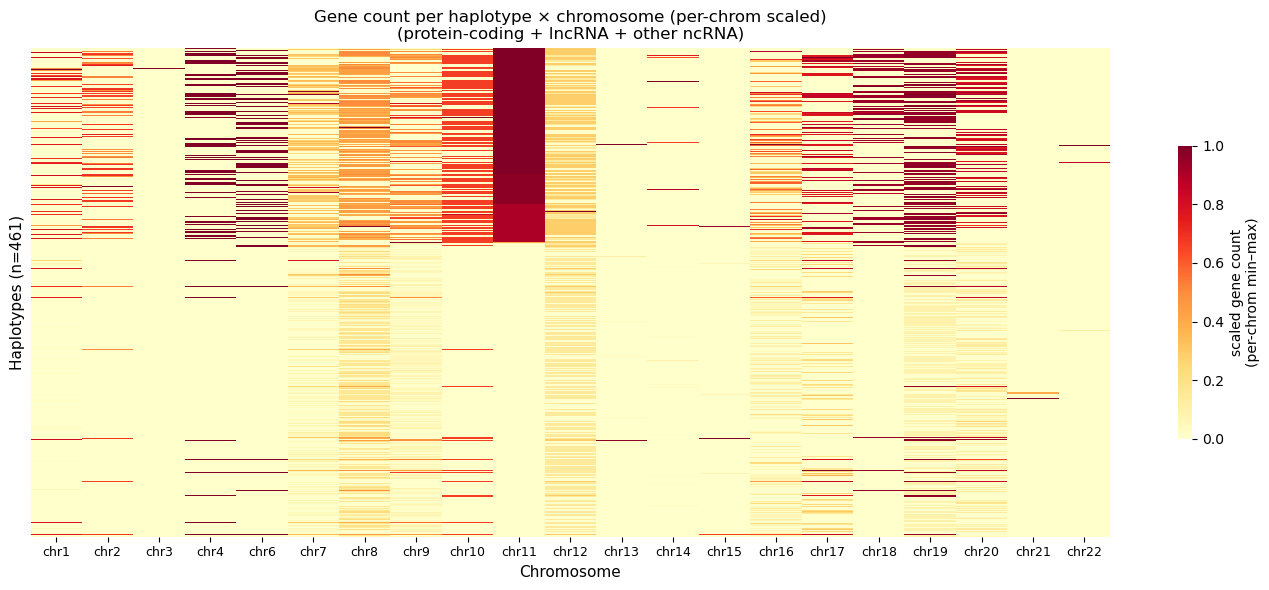

In [43]:
import seaborn as sns

KEEP_BIOTYPES = ["protein-coding", "lncRNA", "other ncRNA"]

# count genes per (sample_id, haplotype, chrom) for kept biotypes
heat_df = (
    df_filtered[df_filtered["biotype_class"].isin(KEEP_BIOTYPES)]
    .groupby(["sample_id", "haplotype", "chrom"])
    .size()
    .reset_index(name="n_genes")
)
heat_df["hap_label"] = heat_df["sample_id"] + "." + heat_df["haplotype"].astype(str)

pivot = heat_df.pivot_table(index="hap_label", columns="chrom", values="n_genes", fill_value=0)
chrom_order = sorted(
    [c for c in pivot.columns if re.search(r'\d+', c)],
    key=lambda c: int(re.search(r'\d+', c).group())
)
pivot = pivot[chrom_order]
pivot_sorted = pivot.loc[pivot["chr11"].sort_values(ascending=False).index]
# normalize each chrom column independently to [0, 1]
pivot_norm = pivot_sorted.copy().astype(float)
for col in pivot_norm.columns:
    col_min = pivot_norm[col].min()
    col_max = pivot_norm[col].max()
    if col_max > col_min:
        pivot_norm[col] = (pivot_norm[col] - col_min) / (col_max - col_min)
    else:
        pivot_norm[col] = 0.0

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(
    pivot_norm,
    ax=ax,
    cmap="YlOrRd",
    linewidths=0,
    xticklabels=True,
    yticklabels=False,
    vmin=0, vmax=1,
    cbar_kws={"label": "scaled gene count\n(per-chrom min–max)", "shrink": 0.6},
)
ax.set_xlabel("Chromosome", fontsize=11)
ax.set_ylabel(f"Haplotypes (n={len(pivot_norm)})", fontsize=11)
ax.set_title("Gene count per haplotype × chromosome (per-chrom scaled)\n(protein-coding + lncRNA + other ncRNA)", fontsize=12)
ax.tick_params(axis='x', labelsize=9)
plt.tight_layout()
plt.show()





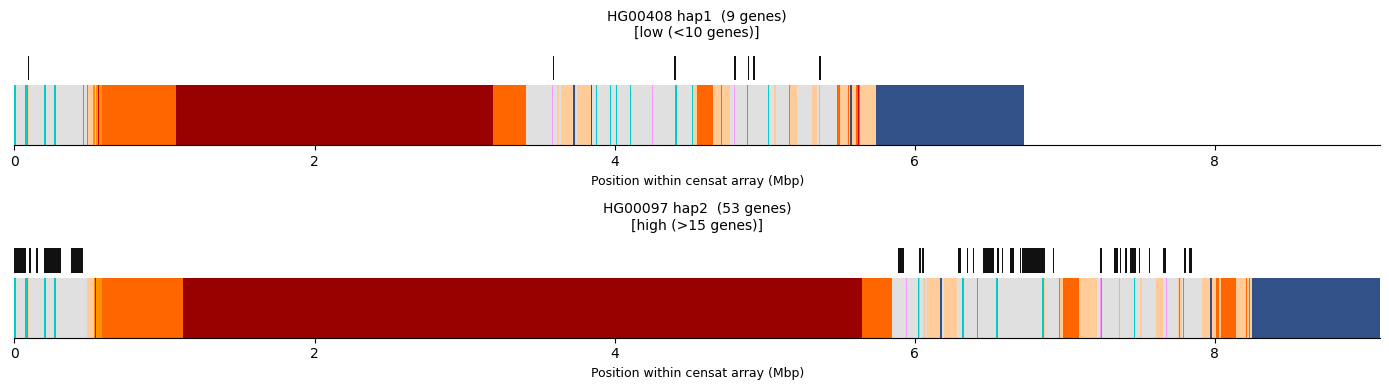

In [29]:
def plot_array(ax, sid, hap, label, region_idx_local, genes_df_local, xlim):
    region = region_idx_local.get((sid, hap))
    if region is None:
        ax.set_title(f"{label}\n(no region)", fontsize=10)
        return
    rs, re_ = region["region_start"], region["region_end"]
    size_mbp = (re_ - rs) / 1e6

    for seg in load_censat(sid, hap, region):
        ax.add_patch(mpatches.Rectangle(
            (seg["start"], 0), seg["end"] - seg["start"], 0.6,
            color=seg["color"], linewidth=0))

    genes = genes_df_local[(genes_df_local["sample_id"] == sid) &
                            (genes_df_local["haplotype"] == hap)]
    for _, g in genes.iterrows():
        g_start = max(0, (g["start"] - rs) / 1e6)
        g_end   = min(size_mbp, (g["end"] - rs) / 1e6)
        ax.add_patch(mpatches.Rectangle(
            (g_start, 0.65), max(g_end - g_start, 0.01), 0.25,
            color="#111111", linewidth=0))

    ax.set_xlim(0, xlim)
    ax.set_ylim(0, 1)
    ax.set_title(f"{sid} hap{hap}  ({len(genes)} genes)\n[{label}]", fontsize=10)
    ax.set_xlabel("Position within censat array (Mbp)", fontsize=9)
    ax.set_yticks([])
    ax.spines[["top", "right", "left"]].set_visible(False)


chrom = "chr20"
low_thresh, high_thresh = 10, 15

chr20_counts = per_hap_chrom[per_hap_chrom["chrom"] == chrom].copy()
chr20_counts["haplotype"] = chr20_counts["haplotype"].astype(str)

low_sample  = chr20_counts[chr20_counts["count"] <  low_thresh].iloc[0]
high_sample = chr20_counts[chr20_counts["count"] > high_thresh].iloc[0]

chr20_regions = regions_df[
    (regions_df["chrom_assignment"] == chrom) & (regions_df["pass_qc"] == True)
].copy()
chr20_regions["haplotype"] = chr20_regions["haplotype"].astype(str)
region_idx_20 = {(r["sample_id"], r["haplotype"]): r for _, r in chr20_regions.iterrows()}

chr20_genes_df = df_filtered[df_filtered["chrom"] == chrom].copy()
chr20_genes_df["haplotype"] = chr20_genes_df["haplotype"].astype(str)

# shared x limit = max array size across both samples
samples = [low_sample, high_sample]
shared_xlim = max(
    (region_idx_20[(r["sample_id"], str(r["haplotype"]))]["region_end"] -
     region_idx_20[(r["sample_id"], str(r["haplotype"]))]["region_start"]) / 1e6
    for r in samples
    if (r["sample_id"], str(r["haplotype"])) in region_idx_20
)

fig, axes = plt.subplots(2, 1, figsize=(14, 4))
plot_array(axes[0], low_sample["sample_id"],  str(low_sample["haplotype"]),
           f"low (<{low_thresh} genes)", region_idx_20, chr20_genes_df, shared_xlim)
plot_array(axes[1], high_sample["sample_id"], str(high_sample["haplotype"]),
           f"high (>{high_thresh} genes)", region_idx_20, chr20_genes_df, shared_xlim)
plt.tight_layout()
plt.show()



In [30]:
for samp, label in [(low_sample, "low"), (high_sample, "high")]:
    sid, hap = samp["sample_id"], str(samp["haplotype"])
    region = region_idx_20.get((sid, hap))
    if region is not None:
        print(f"{label}  {sid} hap{hap}:  {region['sequence_id']}  {region['region_start']}  {region['region_end']}")


low  HG00408 hap1:  HG00408#1#CM085964.1  25920160  32650816
high  HG00097 hap2:  HG00097#2#CM094086.1  25878471  34979133


In [31]:
KEEP_BIOTYPES = {"protein-coding", "lncRNA", "other ncRNA"}

genes_low  = chr20_genes_df[(chr20_genes_df["sample_id"] == sid_low)  &
                             (chr20_genes_df["haplotype"] == hap_low)  &
                             (chr20_genes_df["biotype_class"].isin(KEEP_BIOTYPES))]
genes_high = chr20_genes_df[(chr20_genes_df["sample_id"] == sid_high) &
                             (chr20_genes_df["haplotype"] == hap_high) &
                             (chr20_genes_df["biotype_class"].isin(KEEP_BIOTYPES))]

names_low  = set(genes_low["gene_name"])
names_high = set(genes_high["gene_name"])

only_in_low  = names_low  - names_high
only_in_high = names_high - names_low

print(f"=== Only in LOW ({sid_low} hap{hap_low}): {len(only_in_low)} genes ===")
display(gene_pos(genes_low, reg_low, only_in_low))

print(f"\n=== Only in HIGH ({sid_high} hap{hap_high}): {len(only_in_high)} genes ===")
display(gene_pos(genes_high, reg_high, only_in_high))

print(f"\n=== Shared: {len(names_low & names_high)} genes ===")
display(gene_pos(genes_high, reg_high, names_low & names_high))



NameError: name 'sid_low' is not defined

In [ ]:
chr1_counts = per_hap_chrom[per_hap_chrom["chrom"] == "chr1"]
top = chr1_counts.loc[chr1_counts["count"].idxmax()]
print(top)


sample_id    HG00350
haplotype          1
chrom           chr1
count             40
Name: 260, dtype: object


### Gene exploration

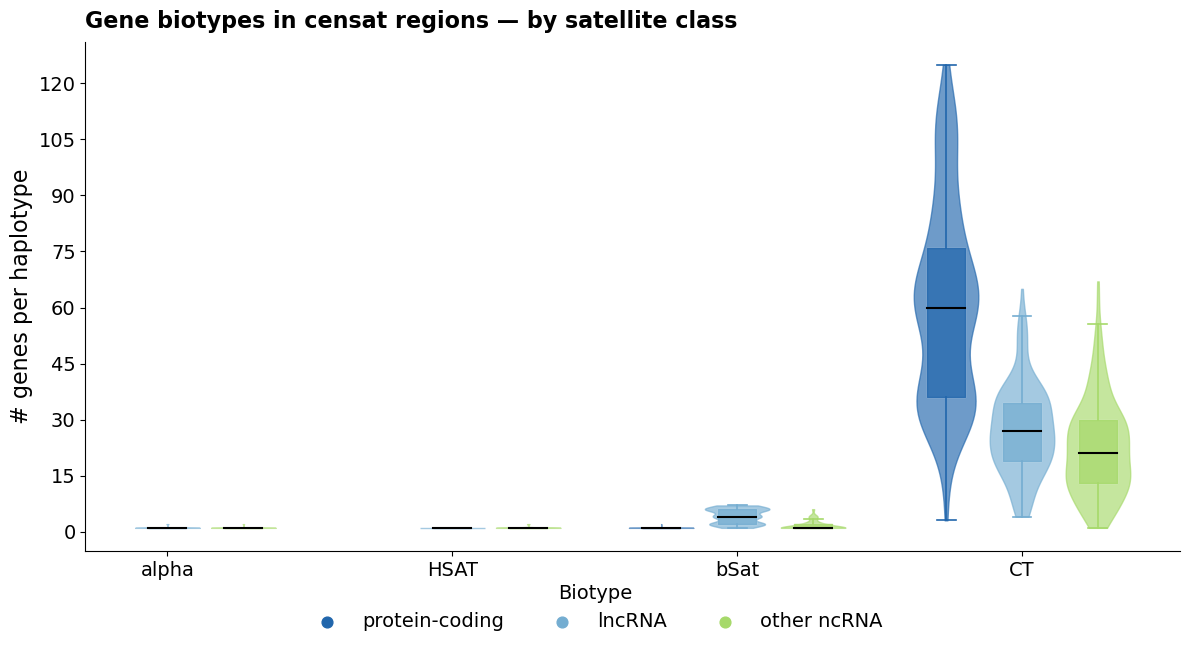

In [ ]:
BIOTYPE_ORDER = ["protein-coding", "lncRNA", "other ncRNA"]

BIOTYPE_COLORS = {
    "protein-coding": "#2166ac",
    "lncRNA":         "#74add1",
    "pseudogene":     "#f46d43",
    "other ncRNA":    "#a6d96a",
    "other coding":   "#d9d9d9",
}

SAT_GROUPS = {
    "alpha": ["active_hor", "hor", "mixedAlpha", "mon"],
    "HSAT":  ["HSAT1", "HSAT2", "HSAT3", "HSAT4", "HSAT5"],
    "bSat":  ["bSat"],
    "CT":    ["CT"],
}
SAT_ORDER_NEW = ["alpha", "HSAT", "bSat", "CT"]
cat_to_satgrp = {c: g for g, cats in SAT_GROUPS.items() for c in cats}

df_filtered_sat = df_filtered.copy()
df_filtered_sat["sat_group"] = df_filtered_sat["censat_category"].map(cat_to_satgrp)
df_filtered_sat = df_filtered_sat.dropna(subset=["sat_group"])

per_hap_sat_condensed = (
    df_filtered_sat
    .groupby(["sample_id", "haplotype", "sat_group", "biotype_class"])
    .size()
    .reset_index(name="count")
)

def make_swarm_panel(ax, data, x_col, x_order, title, xlabel):
    valid_x       = [c for c in x_order if c in data[x_col].unique()]
    valid_biotype = [b for b in BIOTYPE_ORDER if b in data["biotype_class"].unique()]
    data          = data[data[x_col].isin(valid_x)]

    n_biotypes = len(valid_biotype)
    width      = 0.8 / n_biotypes
    x_idx      = {c: i for i, c in enumerate(valid_x)}

    for b_i, biotype in enumerate(valid_biotype):
        sub    = data[data["biotype_class"] == biotype]
        color  = BIOTYPE_COLORS[biotype]
        offset = (b_i - n_biotypes / 2 + 0.5) * width

        for cat in valid_x:
            vals = sub[sub[x_col] == cat]["count"].values
            if len(vals) < 3:
                continue
            xi = x_idx[cat] + offset

            # violin with outline
            parts = ax.violinplot(vals, positions=[xi], widths=width * 0.85,
                                  showextrema=False, showmedians=False)
            for pc in parts["bodies"]:
                pc.set_facecolor(color)
                pc.set_alpha(0.65)
                pc.set_edgecolor(color)
                pc.set_linewidth(1.0)

            # box and whiskers
            q1, med, q3 = np.percentile(vals, [25, 50, 75])
            iqr   = q3 - q1
            lo    = max(vals.min(), q1 - 1.5 * iqr)
            hi    = min(vals.max(), q3 + 1.5 * iqr)
            bw    = width * 0.25
            ax.fill_between([xi - bw, xi + bw], q1, q3,
                             color="white", zorder=3)
            ax.fill_between([xi - bw, xi + bw], q1, q3,
                             color=color, alpha=0.9, zorder=4)
            ax.plot([xi - bw, xi + bw], [med, med],
                    color="black", lw=1.5, zorder=5)
            ax.plot([xi, xi], [lo, q1], color=color, lw=1.2, zorder=3)
            ax.plot([xi, xi], [q3, hi], color=color, lw=1.2, zorder=3)
            ax.plot([xi - bw * 0.5, xi + bw * 0.5], [lo, lo],
                    color=color, lw=1.2, zorder=3)
            ax.plot([xi - bw * 0.5, xi + bw * 0.5], [hi, hi],
                    color=color, lw=1.2, zorder=3)

    ax.set_xticks(range(len(valid_x)))
    ax.set_xticklabels(valid_x, ha="center", fontsize=14)
    ax.set_title(title, fontsize=16, fontweight="bold", pad=10, loc="left")
    ax.set_xlabel(xlabel, fontsize=14)
    ax.set_ylabel("# genes per haplotype", fontsize=16)
    ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(axis="y", labelsize=14)

np.random.seed(42)

fig, ax = plt.subplots(1, 1, figsize=(12, 6))

make_swarm_panel(
    ax, per_hap_sat_condensed,
    x_col="sat_group", x_order=SAT_ORDER_NEW,
    title="Gene biotypes in censat regions — by satellite class",
    xlabel=""
)

handles = [
    plt.scatter([], [], color=BIOTYPE_COLORS[b], s=60, label=b)
    for b in BIOTYPE_ORDER if b in df_filtered_sat["biotype_class"].unique()
]
fig.legend(
    handles=handles, title="Biotype",
    loc="lower center", ncol=5,
    fontsize=14, title_fontsize=14,
    frameon=False, bbox_to_anchor=(0.5, -0.09)
)

plt.tight_layout()
plt.show()



## Copy number variable genes

In [ ]:
### mean absolute deviance 

SAT_GROUPS = {
    "alpha": ["active_hor", "hor", "mixedAlpha", "mon"],
    "HSAT":  ["HSAT1", "HSAT2", "HSAT3", "HSAT4", "HSAT5"],
    "bSat":  ["bSat"],
    "CT":    ["CT"],
}
cat_to_satgrp = {c: g for g, cats in SAT_GROUPS.items() for c in cats}
keep_cats     = set(cat_to_satgrp.keys())

KEEP_BIOTYPES = ["protein-coding", "lncRNA", "other ncRNA"]
df_sub = df_filtered[
    df_filtered["biotype_class"].isin(KEEP_BIOTYPES) &
    df_filtered["censat_category"].isin(keep_cats)
]

all_haps   = df_filtered[["sample_id", "haplotype"]].drop_duplicates()
total_haps = len(all_haps)

# copy count per gene per haplotype
cn = (
    df_sub.groupby(["gene_name", "sample_id", "haplotype"])
    .size()
    .reset_index(name="copy_count")
)

# full haplotype x gene matrix, filling absent observations with 0
cn_pivot = (
    cn.pivot_table(index=["sample_id", "haplotype"], columns="gene_name",
                   values="copy_count", fill_value=0)
    .reindex(pd.MultiIndex.from_frame(all_haps), fill_value=0)
)

# median copy count per gene across all haplotypes (the reference)
gene_medians = cn_pivot.median(axis=0)

# only keep genes with median > 0 (present in >50% of haplotypes)
# and with pct_haplotypes >= 10%
n_present    = (cn_pivot > 0).sum(axis=0)
pct_present  = 100 * n_present / total_haps

valid_genes = pct_present[pct_present >= 10].index
cn_ratio     = cn_pivot[valid_genes].div(gene_medians[valid_genes], axis=1)

valid_genes = pct_present[pct_present >= 10].index

# for genes with median > 0: MAD of ratio from 1.0
# for genes with median == 0: MAD of raw copy count from 0
mad_ratio = {}
for gene in valid_genes:
    vals   = cn_pivot[gene].values
    median = gene_medians[gene]
    if median > 0:
        mad_ratio[gene] = np.mean(np.abs(vals / median - 1))
    else:
        mad_ratio[gene] = np.mean(np.abs(vals))  # deviation from 0

gene_stats = pd.DataFrame({
    "median_cn":      gene_medians[valid_genes],
    "mad_ratio":      pd.Series(mad_ratio),
    "n_haps_present": n_present[valid_genes],
    "pct_haplotypes": pct_present[valid_genes],
})
gene_stats.index.name = "gene_name"
gene_stats = gene_stats.reset_index()


top10_genes = gene_stats.nlargest(10, "mad_ratio")["gene_name"].tolist()

# annotate
rows = []
for gene in top10_genes:
    sub    = df_sub[df_sub["gene_name"] == gene]
    chroms = sorted(sub["chrom"].unique())
    cats   = sorted(sub["censat_category"].unique())
    stats  = gene_stats[gene_stats["gene_name"] == gene].iloc[0]

    rows.append({
        "gene_name":         gene,
        "biotype":           sub["gene_biotype"].mode()[0],
        "median_cn":         round(stats["median_cn"], 2),
        "mad_ratio":         round(stats["mad_ratio"], 3),
        "pct_haplotypes":    round(stats["pct_haplotypes"], 1),
        "n_chroms":          len(chroms),
        "chroms":            ", ".join(chroms),
        "n_censat_cats":     len(cats),
        "censat_categories": ", ".join(cats),
    })

results_df = pd.DataFrame(rows).sort_values("mad_ratio", ascending=False).reset_index(drop=True)
display(results_df)


,gene_name,biotype,median_cn,mad_ratio,pct_haplotypes,n_chroms,chroms,n_censat_cats,censat_categories
0,LINC02799,lncRNA,0.0,1.575,34.1,3,"chr1, chr16, chr7",1,CT
1,MIR4477A,miRNA,0.0,0.876,31.5,7,"chr1, chr13, chr14, chr15, chr20, chr22, chr9",2,"CT, HSAT3"
2,Y_RNA,misc_RNA,0.0,0.857,31.5,9,"chr1, chr12, chr13, chr14, chr15, chr20, chr22...",1,CT
3,MIR4477B,miRNA,0.0,0.796,38.4,7,"chr1, chr13, chr14, chr15, chr20, chr22, chr9",3,"CT, HSAT3, active_hor"
4,TTTY17C,lncRNA,1.0,0.479,52.1,1,chr8,1,bSat
5,LINC00664,lncRNA,1.0,0.466,53.4,1,chr19,1,bSat
6,LINC01224,lncRNA,1.0,0.460,54.0,1,chr19,1,bSat
7,LINC01858,lncRNA,1.0,0.460,54.0,1,chr19,1,bSat
8,LINC01859,lncRNA,1.0,0.460,54.0,1,chr19,1,bSat
9,FOLH1,protein_coding,0.0,0.399,39.9,1,chr11,1,CT


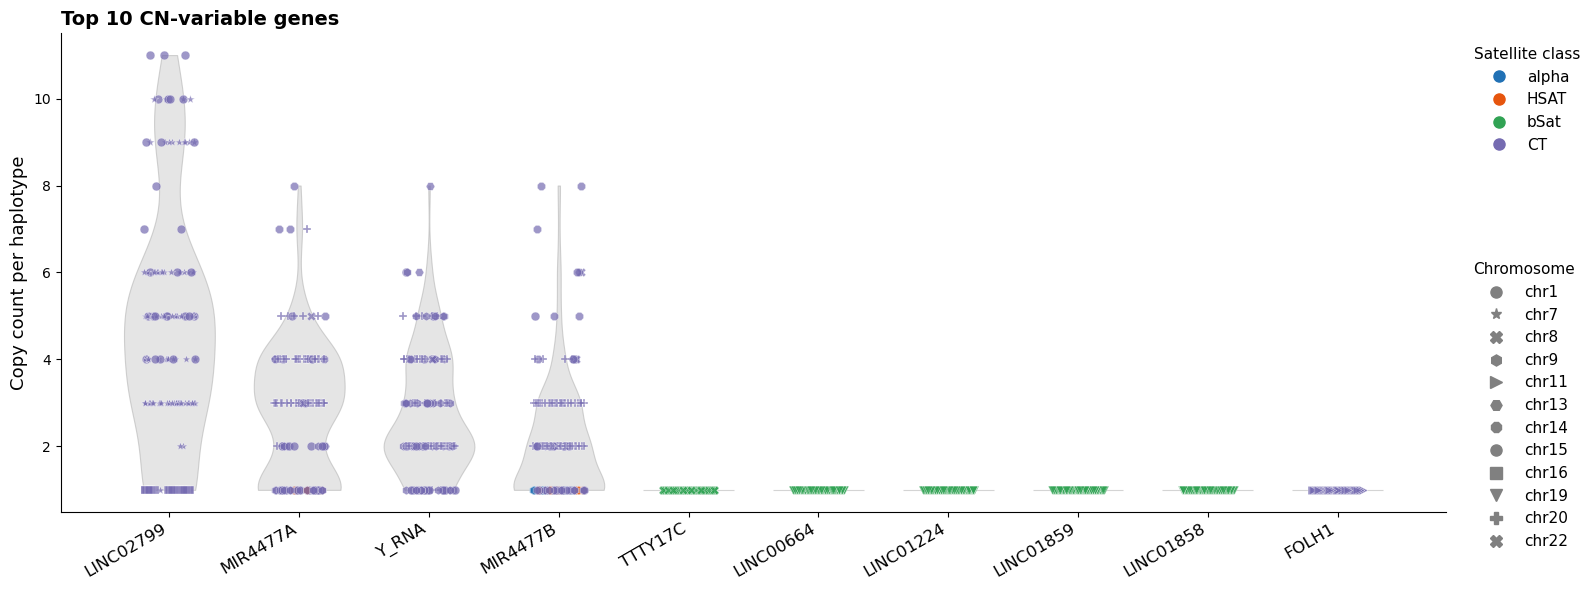

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.lines as mlines
import numpy as np
from itertools import cycle

SAT_COLORS = {
    "alpha": "#2171b5",
    "HSAT":  "#e6550d",
    "bSat":  "#31a354",
    "CT":    "#756bb1",
}

CHROM_MARKERS = {
    chrom: m for chrom, m in zip(
        CHROM_ORDER,
        cycle(['o', 's', '^', 'D', 'v', 'P', '*', 'X', 'h', '<', '>', 'p', 'H', '8'])
    )
}

gene_meta = df_sub[df_sub["gene_name"].isin(top10_genes)].copy()
gene_meta["sat_group"] = gene_meta["censat_category"].map(cat_to_satgrp)

dominant = (
    gene_meta
    .groupby(["gene_name", "sample_id", "haplotype"])
    .agg(
        sat_group = ("sat_group", lambda x: x.mode()[0]),
        chrom     = ("chrom",     lambda x: x.mode()[0]),
    )
    .reset_index()
)

plot_data = (
    cn[cn["gene_name"].isin(top10_genes)]
    .merge(dominant, on=["gene_name", "sample_id", "haplotype"], how="left")
)

gene_order = (
    gene_stats[gene_stats["gene_name"].isin(top10_genes)]
    .sort_values("mad_ratio", ascending=False)["gene_name"]
    .tolist()
)

x_idx = {g: i for i, g in enumerate(gene_order)}

np.random.seed(42)
fig, ax = plt.subplots(figsize=(16, 6))

for gene in gene_order:
    vals = plot_data[plot_data["gene_name"] == gene]["copy_count"].values
    xi   = x_idx[gene]
    if len(vals) >= 3:
        parts = ax.violinplot(vals, positions=[xi], widths=0.7,
                              showextrema=False, showmedians=False)
        for pc in parts["bodies"]:
            pc.set_facecolor("#cccccc")
            pc.set_alpha(0.5)
            pc.set_edgecolor("#aaaaaa")
            pc.set_linewidth(0.8)

for _, row in plot_data.iterrows():
    xi     = x_idx[row["gene_name"]]
    color  = SAT_COLORS.get(row["sat_group"], "#888888")
    marker = CHROM_MARKERS.get(row["chrom"], "o")
    jitter = np.random.uniform(-0.2, 0.2)
    ax.scatter(xi + jitter, row["copy_count"],
               c=color, marker=marker, s=40, alpha=0.7,
               linewidths=0.3, edgecolors="white", zorder=3)

ax.set_xticks(range(len(gene_order)))
ax.set_xticklabels(gene_order, rotation=30, ha="right", fontsize=12)
ax.set_ylabel("Copy count per haplotype", fontsize=13)
ax.set_title("Top 10 CN-variable genes", fontsize=14, fontweight="bold", loc="left")
ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))
ax.spines[["top", "right"]].set_visible(False)

sat_handles = [
    mlines.Line2D([], [], color=c, marker='o', linestyle='None', markersize=8, label=g)
    for g, c in SAT_COLORS.items()
]
chroms_present = plot_data["chrom"].dropna().unique()
chrom_handles  = [
    mlines.Line2D([], [], color="grey", marker=CHROM_MARKERS[c], linestyle='None',
                  markersize=8, label=c)
    for c in CHROM_ORDER if c in chroms_present
]

leg1 = ax.legend(handles=sat_handles, title="Satellite class",
                 loc="upper left", bbox_to_anchor=(1.01, 1),
                 frameon=False, fontsize=11, title_fontsize=11)
ax.add_artist(leg1)
ax.legend(handles=chrom_handles, title="Chromosome",
          loc="upper left", bbox_to_anchor=(1.01, 0.55),
          frameon=False, fontsize=11, title_fontsize=11)

plt.tight_layout()
plt.show()



,gene_name,biotype,median_cn,variance,pct_haplotypes,n_chroms,chroms,n_censat_cats,censat_categories
0,LINC02799,lncRNA,0.0,7.31,34.1,3,"chr1, chr16, chr7",1,CT
1,MIR4477A,miRNA,0.0,2.38,31.5,7,"chr1, chr13, chr14, chr15, chr20, chr22, chr9",2,"CT, HSAT3"
2,Y_RNA,misc_RNA,0.0,2.19,31.5,9,"chr1, chr12, chr13, chr14, chr15, chr20, chr22...",1,CT
3,MIR4477B,miRNA,0.0,1.71,38.4,7,"chr1, chr13, chr14, chr15, chr20, chr22, chr9",3,"CT, HSAT3, active_hor"
4,KCNJ18,protein_coding,0.0,0.47,13.2,1,chr17,1,CT
5,MIR3156-2,miRNA,0.0,0.45,12.8,1,chr18,1,CT
6,U6,snRNA,0.0,0.41,28.6,5,"chr13, chr14, chr20, chr22, chr9",1,CT
7,SNORA70,snoRNA,0.0,0.34,19.3,3,"chr13, chr14, chr9",1,CT
8,FAM182B,lncRNA,0.0,0.33,15.2,1,chr20,1,CT
9,MIR3118-2,miRNA,0.0,0.33,20.2,4,"chr14, chr22, chr4, chr9",1,CT


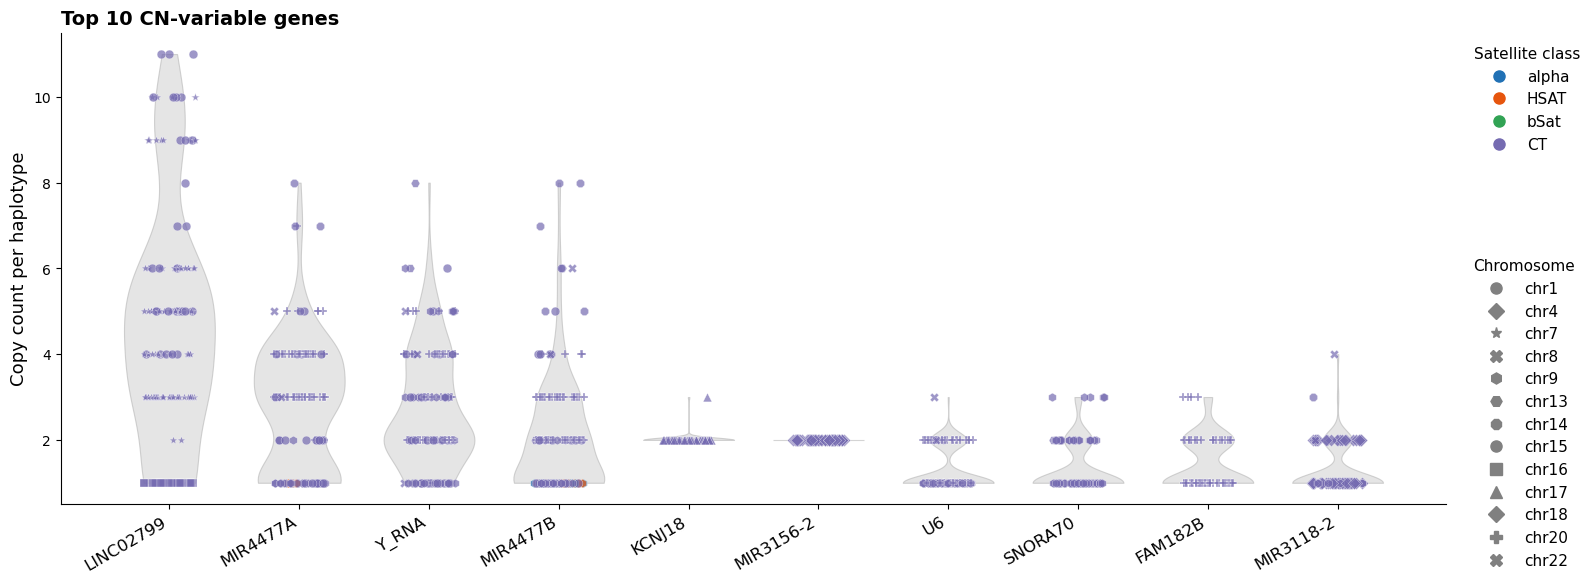

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.lines as mlines
import numpy as np
from itertools import cycle

SAT_GROUPS = {
    "alpha": ["active_hor", "hor", "mixedAlpha", "mon"],
    "HSAT":  ["HSAT1", "HSAT2", "HSAT3", "HSAT4", "HSAT5"],
    "bSat":  ["bSat"],
    "CT":    ["CT"],
}
cat_to_satgrp = {c: g for g, cats in SAT_GROUPS.items() for c in cats}
keep_cats     = set(cat_to_satgrp.keys())

KEEP_BIOTYPES = ["protein-coding", "lncRNA", "other ncRNA"]
df_sub = df_filtered[
    df_filtered["biotype_class"].isin(KEEP_BIOTYPES) &
    df_filtered["censat_category"].isin(keep_cats)
]

all_haps   = df_filtered[["sample_id", "haplotype"]].drop_duplicates()
total_haps = len(all_haps)

# copy count per gene per haplotype
cn = (
    df_sub.groupby(["gene_name", "sample_id", "haplotype"])
    .size()
    .reset_index(name="copy_count")
)

# full haplotype x gene matrix with 0s for absent
cn_pivot = (
    cn.pivot_table(index=["sample_id", "haplotype"], columns="gene_name",
                   values="copy_count", fill_value=0)
    .reindex(pd.MultiIndex.from_frame(all_haps), fill_value=0)
)

gene_medians = cn_pivot.median(axis=0)
n_present    = (cn_pivot > 0).sum(axis=0)
pct_present  = 100 * n_present / total_haps

valid_genes = pct_present[pct_present >= 10].index

gene_stats = pd.DataFrame({
    "median_cn":      gene_medians[valid_genes],
    "variance":       cn_pivot[valid_genes].var(axis=0),
    "n_haps_present": n_present[valid_genes],
    "pct_haplotypes": pct_present[valid_genes],
})
gene_stats.index.name = "gene_name"
gene_stats = gene_stats.reset_index()

top10_genes = gene_stats.nlargest(10, "variance")["gene_name"].tolist()

# annotation table
rows = []
for gene in top10_genes:
    sub    = df_sub[df_sub["gene_name"] == gene]
    chroms = sorted(sub["chrom"].unique())
    cats   = sorted(sub["censat_category"].unique())
    stats  = gene_stats[gene_stats["gene_name"] == gene].iloc[0]
    rows.append({
        "gene_name":         gene,
        "biotype":           sub["gene_biotype"].mode()[0],
        "median_cn":         round(stats["median_cn"], 2),
        "variance":          round(stats["variance"], 2),
        "pct_haplotypes":    round(stats["pct_haplotypes"], 1),
        "n_chroms":          len(chroms),
        "chroms":            ", ".join(chroms),
        "n_censat_cats":     len(cats),
        "censat_categories": ", ".join(cats),
    })

results_df = pd.DataFrame(rows).sort_values("variance", ascending=False).reset_index(drop=True)
display(results_df)

# ── plot ──────────────────────────────────────────────────────────────────────
SAT_COLORS = {
    "alpha": "#2171b5",
    "HSAT":  "#e6550d",
    "bSat":  "#31a354",
    "CT":    "#756bb1",
}
CHROM_MARKERS = {
    chrom: m for chrom, m in zip(
        CHROM_ORDER,
        cycle(['o', 's', '^', 'D', 'v', 'P', '*', 'X', 'h', '<', '>', 'p', 'H', '8'])
    )
}

gene_meta = df_sub[df_sub["gene_name"].isin(top10_genes)].copy()
gene_meta["sat_group"] = gene_meta["censat_category"].map(cat_to_satgrp)

dominant = (
    gene_meta
    .groupby(["gene_name", "sample_id", "haplotype"])
    .agg(
        sat_group = ("sat_group", lambda x: x.mode()[0]),
        chrom     = ("chrom",     lambda x: x.mode()[0]),
    )
    .reset_index()
)

plot_data = (
    cn[cn["gene_name"].isin(top10_genes)]
    .merge(dominant, on=["gene_name", "sample_id", "haplotype"], how="left")
)

gene_order = (
    gene_stats[gene_stats["gene_name"].isin(top10_genes)]
    .sort_values("variance", ascending=False)["gene_name"]
    .tolist()
)
x_idx = {g: i for i, g in enumerate(gene_order)}

np.random.seed(42)
fig, ax = plt.subplots(figsize=(16, 6))

for gene in gene_order:
    vals = plot_data[plot_data["gene_name"] == gene]["copy_count"].values
    xi   = x_idx[gene]
    if len(vals) >= 3:
        parts = ax.violinplot(vals, positions=[xi], widths=0.7,
                              showextrema=False, showmedians=False)
        for pc in parts["bodies"]:
            pc.set_facecolor("#cccccc")
            pc.set_alpha(0.5)
            pc.set_edgecolor("#aaaaaa")
            pc.set_linewidth(0.8)

for _, row in plot_data.iterrows():
    xi     = x_idx[row["gene_name"]]
    color  = SAT_COLORS.get(row["sat_group"], "#888888")
    marker = CHROM_MARKERS.get(row["chrom"], "o")
    jitter = np.random.uniform(-0.2, 0.2)
    ax.scatter(xi + jitter, row["copy_count"],
               c=color, marker=marker, s=40, alpha=0.7,
               linewidths=0.3, edgecolors="white", zorder=3)

ax.set_xticks(range(len(gene_order)))
ax.set_xticklabels(gene_order, rotation=30, ha="right", fontsize=12)
ax.set_ylabel("Copy count per haplotype", fontsize=13)
ax.set_title("Top 10 CN-variable genes", fontsize=14, fontweight="bold", loc="left")
ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))
ax.spines[["top", "right"]].set_visible(False)

sat_handles = [
    mlines.Line2D([], [], color=c, marker='o', linestyle='None', markersize=8, label=g)
    for g, c in SAT_COLORS.items()
]
chroms_present = plot_data["chrom"].dropna().unique()
chrom_handles  = [
    mlines.Line2D([], [], color="grey", marker=CHROM_MARKERS[c], linestyle='None',
                  markersize=8, label=c)
    for c in CHROM_ORDER if c in chroms_present
]

leg1 = ax.legend(handles=sat_handles, title="Satellite class",
                 loc="upper left", bbox_to_anchor=(1.01, 1),
                 frameon=False, fontsize=11, title_fontsize=11)
ax.add_artist(leg1)
ax.legend(handles=chrom_handles, title="Chromosome",
          loc="upper left", bbox_to_anchor=(1.01, 0.55),
          frameon=False, fontsize=11, title_fontsize=11)

plt.tight_layout()
plt.show()


/data/tmp/ipykernel_1096874/4076144061.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap("tab20")


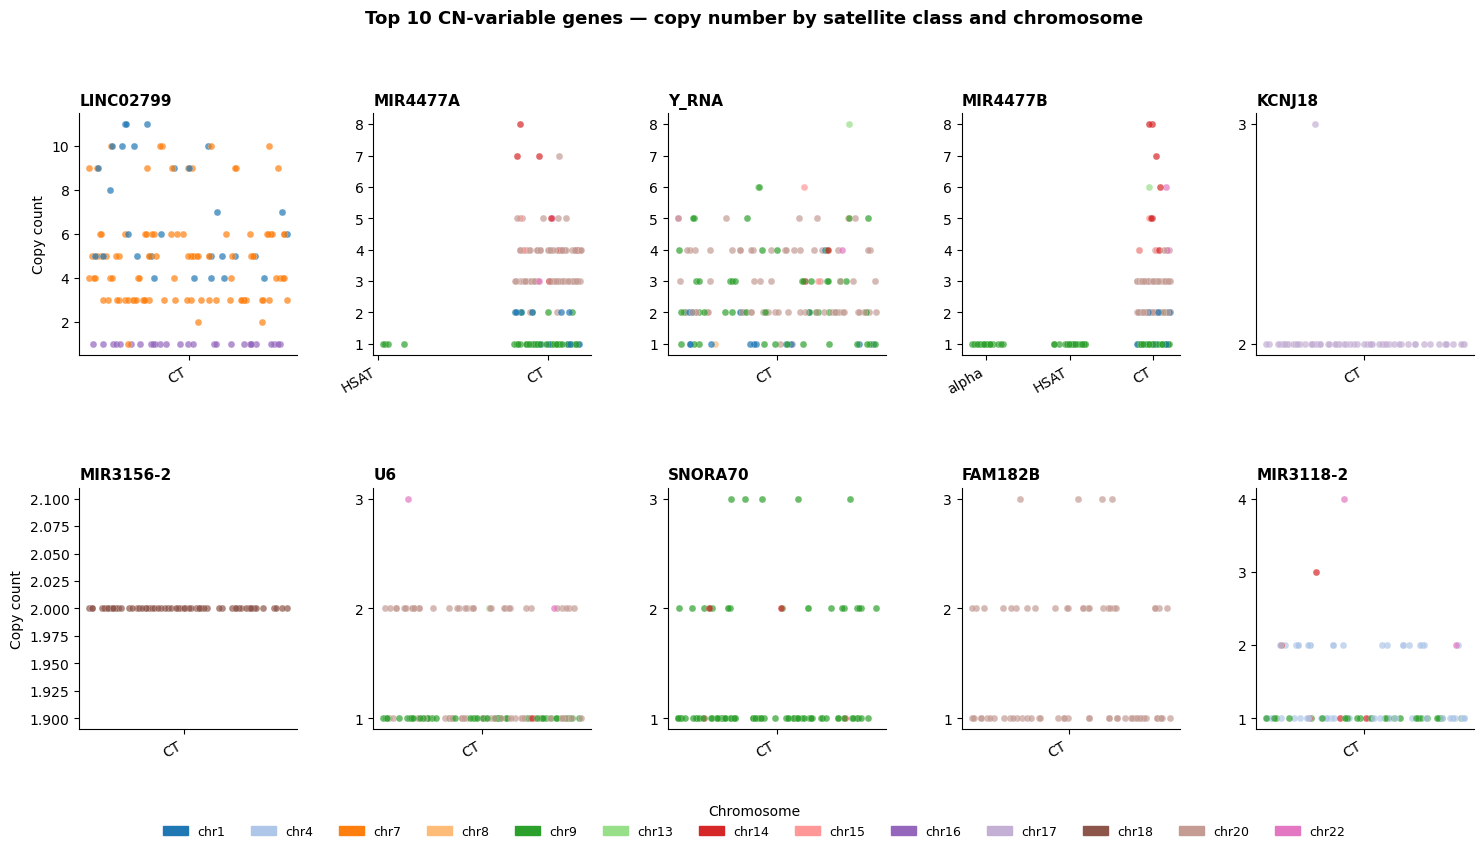

In [ ]:
from matplotlib.cm import get_cmap
import matplotlib.patches as mpatches

# color per chrom
cmap = get_cmap("tab20")
chroms_all    = sorted(dominant["chrom"].dropna().unique(),
                       key=lambda c: CHROM_ORDER.index(c) if c in CHROM_ORDER else 99)
chrom_colors  = {c: cmap(i % 20) for i, c in enumerate(chroms_all)}

ncols = 5
nrows = 2
fig, axes = plt.subplots(nrows, ncols, figsize=(18, 8),
                         gridspec_kw={"hspace": 0.55, "wspace": 0.35})
axes = axes.flatten()

np.random.seed(42)

for ax_i, gene in enumerate(gene_order):
    ax  = axes[ax_i]
    sub = plot_data[plot_data["gene_name"] == gene]

    sat_cats = [s for s in SAT_GROUPS.keys() if s in sub["sat_group"].unique()]
    x_idx_sat = {s: i for i, s in enumerate(sat_cats)}

    for _, row in sub.iterrows():
        xi     = x_idx_sat.get(row["sat_group"], 0)
        color  = chrom_colors.get(row["chrom"], "#888888")
        jitter = np.random.uniform(-0.2, 0.2)
        ax.scatter(xi + jitter, row["copy_count"],
                   color=color, s=25, alpha=0.7,
                   linewidths=0.2, edgecolors="white", zorder=3)

    ax.set_xticks(range(len(sat_cats)))
    ax.set_xticklabels(sat_cats, fontsize=10, rotation=30, ha="right")
    ax.set_title(gene, fontsize=11, fontweight="bold", loc="left")
    ax.set_ylabel("Copy count" if ax_i % ncols == 0 else "", fontsize=10)
    ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(axis="y", labelsize=10)

for ax_i in range(len(gene_order), len(axes)):
    axes[ax_i].set_visible(False)

chrom_handles = [
    mpatches.Patch(color=chrom_colors[c], label=c)
    for c in chroms_all
]
fig.legend(handles=chrom_handles, title="Chromosome",
           loc="lower center", ncol=len(chroms_all),
           fontsize=9, title_fontsize=10,
           frameon=False, bbox_to_anchor=(0.5, -0.04))

fig.suptitle("Top 10 CN-variable genes — copy number by satellite class and chromosome",
             fontsize=13, fontweight="bold", y=1.01)
plt.show()
